In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('Datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv')

Data Preprocessing and Handling

In [7]:
# Checiking shape of the dataset
df.shape

(7043, 21)

In [8]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [9]:
# Checking datatypes of columns
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Type Casting Total charges column

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [12]:
# Checking for Null Values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [13]:
# Droping all Null Values
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
# Removing CustomerID column
df.drop(columns='customerID', inplace=True)

In [16]:
# Checking for Duplicate values
df.duplicated().sum()

np.int64(22)

In [17]:
# Removing Duplicate values
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.shape

(7010, 20)

In [20]:
# Checking number of Unique values in each column
df.nunique()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                72
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1584
TotalCharges        6530
Churn                  2
dtype: int64

In [21]:
columns = df.columns
columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [22]:
for i in columns:
    print(i, df[i].unique(), '\n')

gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str 

SeniorCitizen [0 1] 

Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str 

Dependents <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str 

tenure [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39] 

PhoneService <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str 

MultipleLines <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str 

InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str 

OnlineSecurity <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str 

OnlineBackup <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str 

DeviceProtection <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str 

TechSupport <

Descriptive Statistics

In [23]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


# Exploratory Data Analysis (EDA)

Performed exploratory data analysis using statistical summaries and visualizations to understand data patterns and relationships. Identified key factors influencing churn, such as tenure, contract type, and monthly charges, and detected class imbalance, which guided further preprocessing and model building.

## Customer Demographics

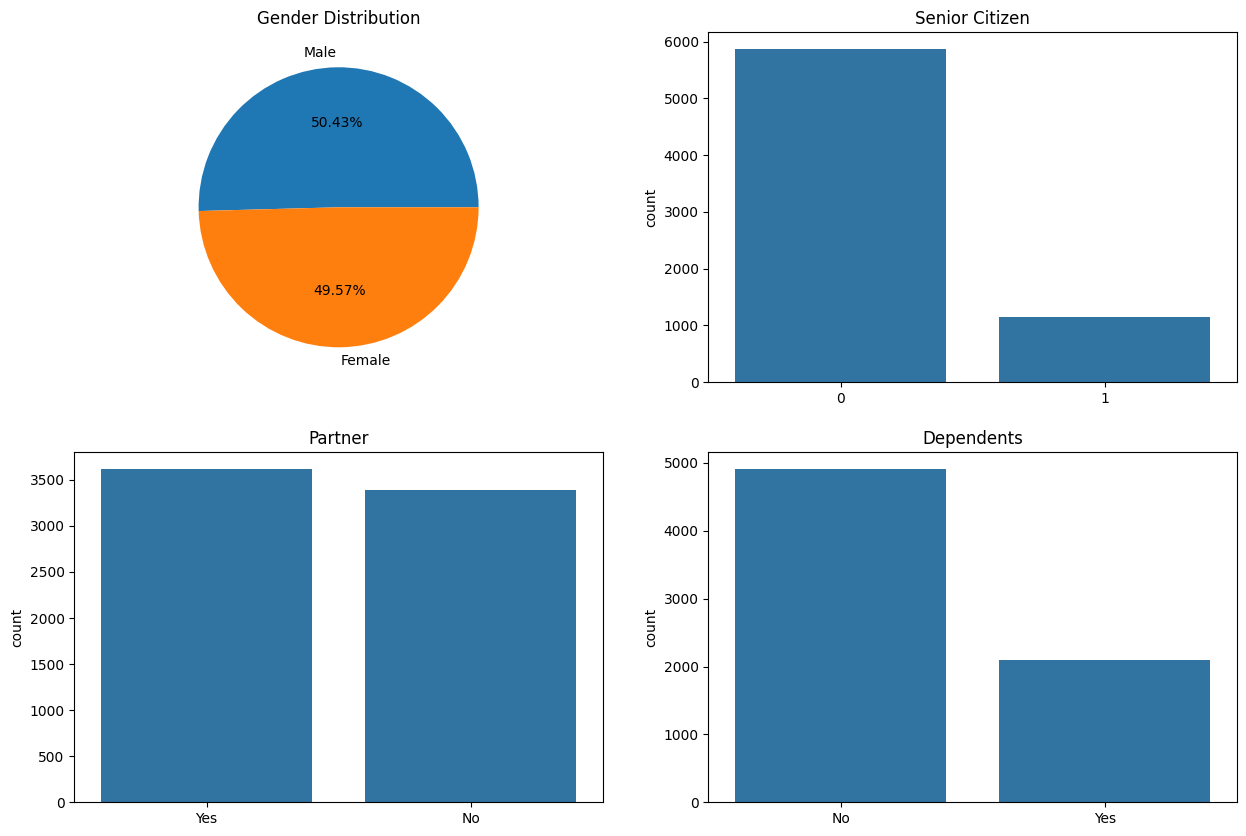

In [24]:
plt.figure(figsize=(15,10))

#Gender Distribution
plt.subplot(2, 2, 1)
plt.pie(df['gender'].value_counts(),labels=['Male','Female'],autopct='%1.2f%%')
plt.title('Gender Distribution')

#Senior Citizen Distribution
plt.subplot(2, 2, 2)
sns.barplot(y = df['SeniorCitizen'].value_counts(), x = df['SeniorCitizen'].unique()).set_title('Senior Citizen')

#Partner Distribution
plt.subplot(2, 2, 3)
sns.barplot(y = df['Partner'].value_counts(), x = df['Partner'].unique()).set_title('Partner')

#Dependents Distribution
plt.subplot(2, 2, 4)
sns.barplot(y = df['Dependents'].value_counts(), x = df['Dependents'].unique()).set_title('Dependents')


plt.show()

### Customer Demographics Insights

- The gender distribution is almost evenly split, with a nearly equal proportion of male and female customers.

- A significant majority of customers are not senior citizens, indicating a younger customer base.

- The number of customers with partners and without partners is fairly balanced, showing no strong dominance of either group.

- Most customers do not have dependents, suggesting that a large portion of the customer base is independent.

## Services

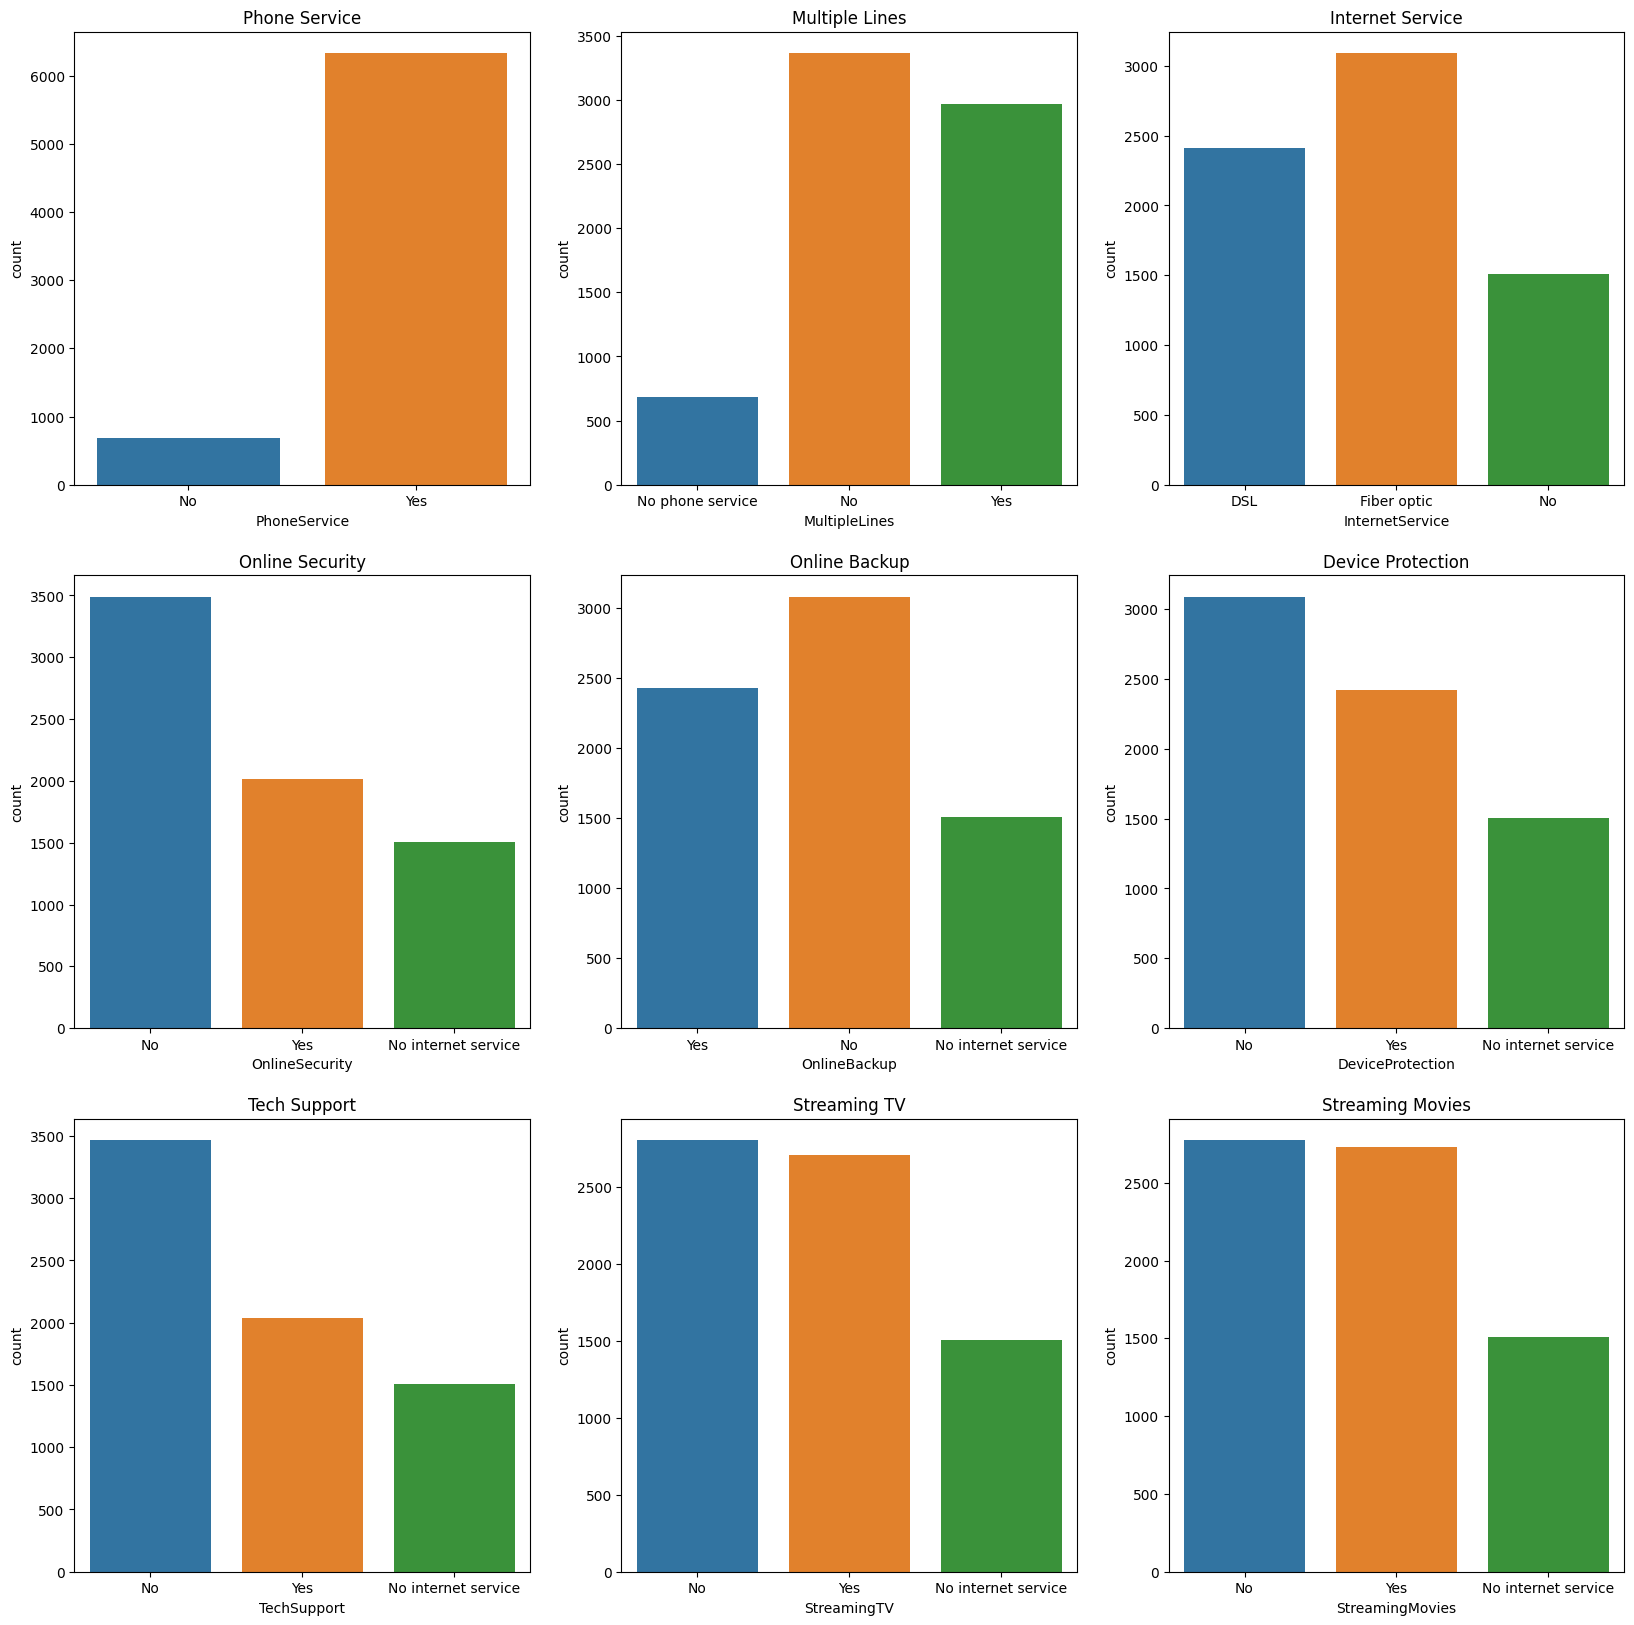

In [25]:
plt.figure(figsize=(20, 20))

#phone service
plt.subplot(3,3,1)
sns.countplot(x=df['PhoneService'],hue=df['PhoneService']).set_title("Phone Service")

#Multiple Lines
plt.subplot(3,3,2)
sns.countplot(x=df['MultipleLines'],hue=df['MultipleLines']).set_title("Multiple Lines")

#Internet Service
plt.subplot(3,3,3)
sns.countplot(x=df['InternetService'],hue=df['InternetService']).set_title("Internet Service")

#Online Security
plt.subplot(3,3,4)
sns.countplot(x=df['OnlineSecurity'],hue=df['OnlineSecurity']).set_title("Online Security")

#Online Backup
plt.subplot(3,3,5)
sns.countplot(x=df['OnlineBackup'],hue=df['OnlineBackup']).set_title("Online Backup")

#Device Protection
plt.subplot(3,3,6)
sns.countplot(x=df['DeviceProtection'],hue=df['DeviceProtection']).set_title("Device Protection")

#Tech Support
plt.subplot(3,3,7)
sns.countplot(x=df['TechSupport'],hue=df['TechSupport']).set_title("Tech Support")

#Streaming TV
plt.subplot(3,3,8)
sns.countplot(x=df['StreamingTV'],hue=df['StreamingTV']).set_title("Streaming TV")

#Streaming Movies
plt.subplot(3,3,9)
sns.countplot(x=df['StreamingMovies'],hue=df['StreamingMovies']).set_title("Streaming Movies")

plt.show()

#### Service Subscription Insights

- **Phone Service:** Most customers have phone service, with very few not using it.

- **Multiple Lines:** Slightly more customers do not use multiple lines compared to those who do.

- **Internet Service:** Fiber optic is the most used internet service, followed by DSL and no internet.

- **Online Security:** A majority of customers do not use online security services.

- **Online Backup:** More customers do not use online backup compared to those who use it.

- **Device Protection:** Most customers do not use device protection services.

- **Tech Support:** A large portion of customers do not use tech support services.

- **Streaming TV:** Usage of streaming TV is almost evenly distributed.

- **Streaming Movies:** Streaming movies usage is also nearly evenly distributed.

## Billing and Charges

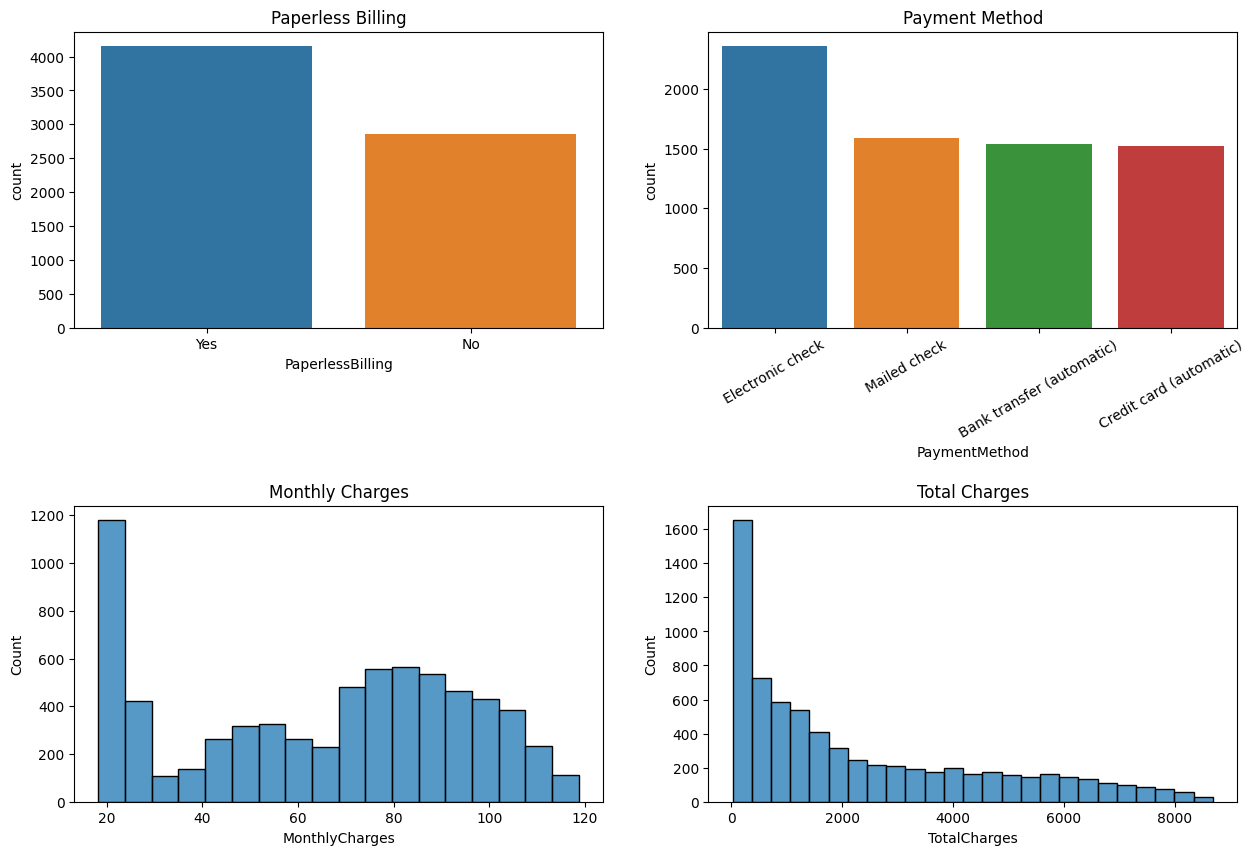

In [26]:
plt.figure(figsize=(15,10))
plt.subplots_adjust(hspace=.6)

#papaerless billing
plt.subplot(2,2,1)
sns.countplot(x = df['PaperlessBilling'],hue=df['PaperlessBilling']).set_title('Paperless Billing')

#Payment Method
plt.subplot(2,2,2)
sns.countplot(x = df['PaymentMethod'],hue=df['PaymentMethod']).set_title('Payment Method')
plt.xticks(rotation=30)

#Monthly Charges
plt.subplot(2,2,3)
sns.histplot(x=df['MonthlyCharges']).set_title("Monthly Charges")

#Total Charges
plt.subplot(2,2,4)
sns.histplot(x=df['TotalCharges']).set_title("Total Charges")

plt.show()

### Billing and Charges Insights 

- Most customers prefer paperless billing, but a significant number still use paper bills.
- Electronic check is the most common payment method, followed by mailed checks, bank transfers, and credit cards.
- Many customers pay around 20, per month, but some pay much higher monthly charges.
- Most customers have total charges below $2000, but a few have much higher totals, likely due to long tenure or multiple services.

## Tenure and Contract

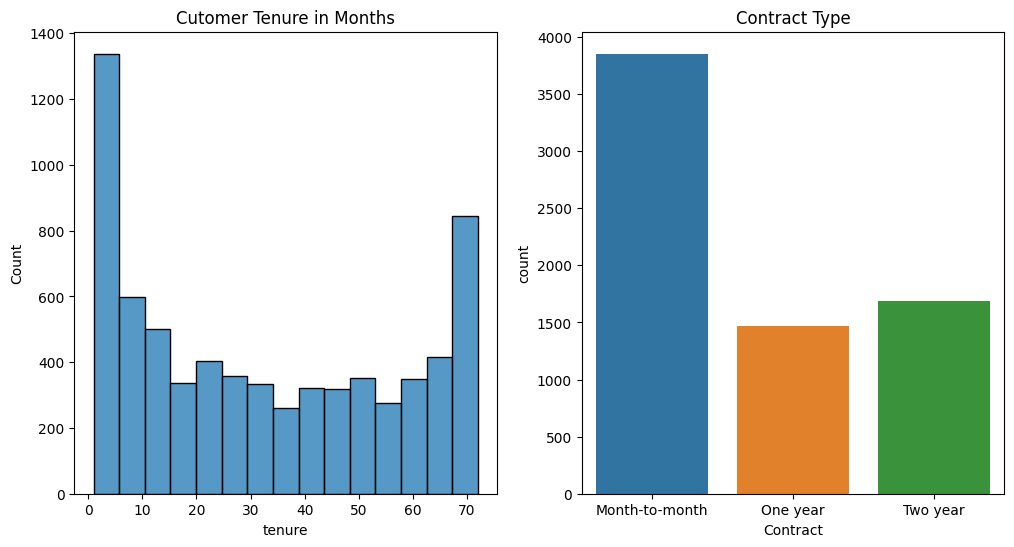

In [27]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(x = 'tenure', data = df).set_title('Cutomer Tenure in Months')

plt.subplot(1,2,2)
sns.countplot(x = 'Contract', data = df,hue='Contract').set_title('Contract Type')

plt.show()

### Tenure and Contract Insights

- Most customers have a short tenure (less than a year) with the company.
- The majority of customers are on month-to-month contracts.
- A significant number of loyal customers have a tenure close to 70 months.
- Two-year contracts are the next most popular after month-to-month.

## Churn Count 

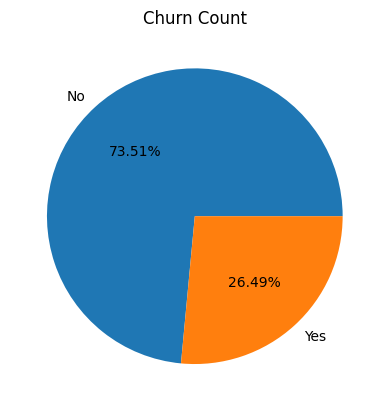

In [28]:
plt.pie(x = df['Churn'].value_counts(), labels = df['Churn'].unique(), autopct = '%1.2f%%')
plt.title('Churn Count')
plt.show()

**Churn Rate Insights**

- Only about 26% of customers have churned, while the majority have stayed.
- This indicates that the company is relatively successful at retaining its customers.

Monitoring churn rate is crucial for business growth and customer retention strategies.In the dataset, the number of churning customers is very less as compared to non churning. Only 26.49% churnned from the telecom company. This could be a potential proof, that company is quite good at retaning its customers.

## Analyzing Churn by Customer Characteristics

### Customer Demographics and Churn

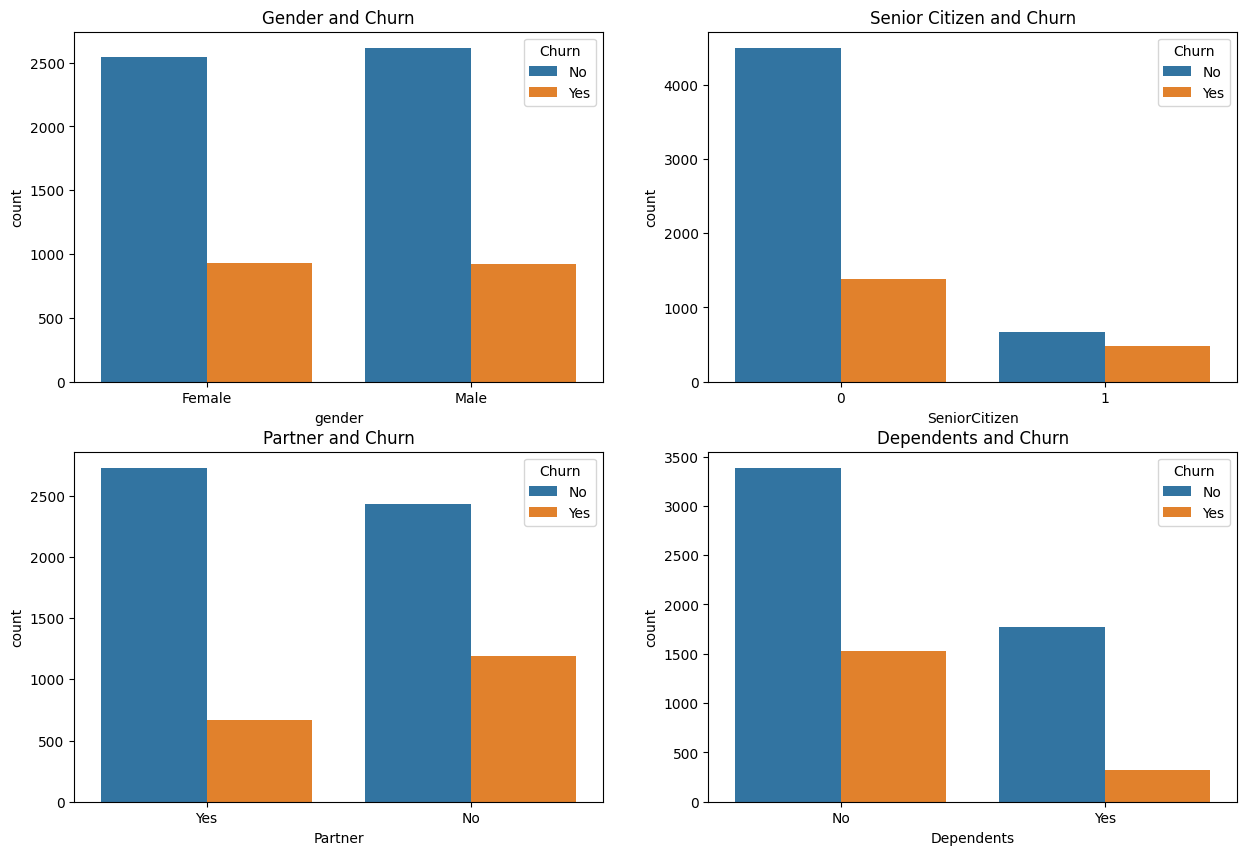

In [29]:
plt.figure(figsize=(15,10))

#Gender Distribution
plt.subplot(2, 2, 1)
sns.countplot(x=df['gender'],hue=df['Churn']).set_title("Gender and Churn")

#Senior Citizen Distribution
plt.subplot(2, 2, 2)
sns.countplot(x=df['SeniorCitizen'],hue=df['Churn']).set_title("Senior Citizen and Churn")

#Partner Distribution
plt.subplot(2, 2, 3)
sns.countplot(x=df['Partner'],hue=df['Churn']).set_title("Partner and Churn")

#Dependents Distribution
plt.subplot(2, 2, 4)
sns.countplot(x=df['Dependents'],hue=df['Churn']).set_title("Dependents and Churn")

plt.show()

**Churn bt Demographics**
- Churn is nearly одинаков across genders, indicating gender has minimal impact on churn.
- Senior citizens show a relatively higher churn proportion compared to non-senior customers.
- Customers without partners are more likely to churn than those with partners.
- Customers without dependents have a higher churn rate compared to those with dependents.

Churn is more influenced by customer lifestyle factors (age, partner, dependents) than by gender.

### Services and Churn

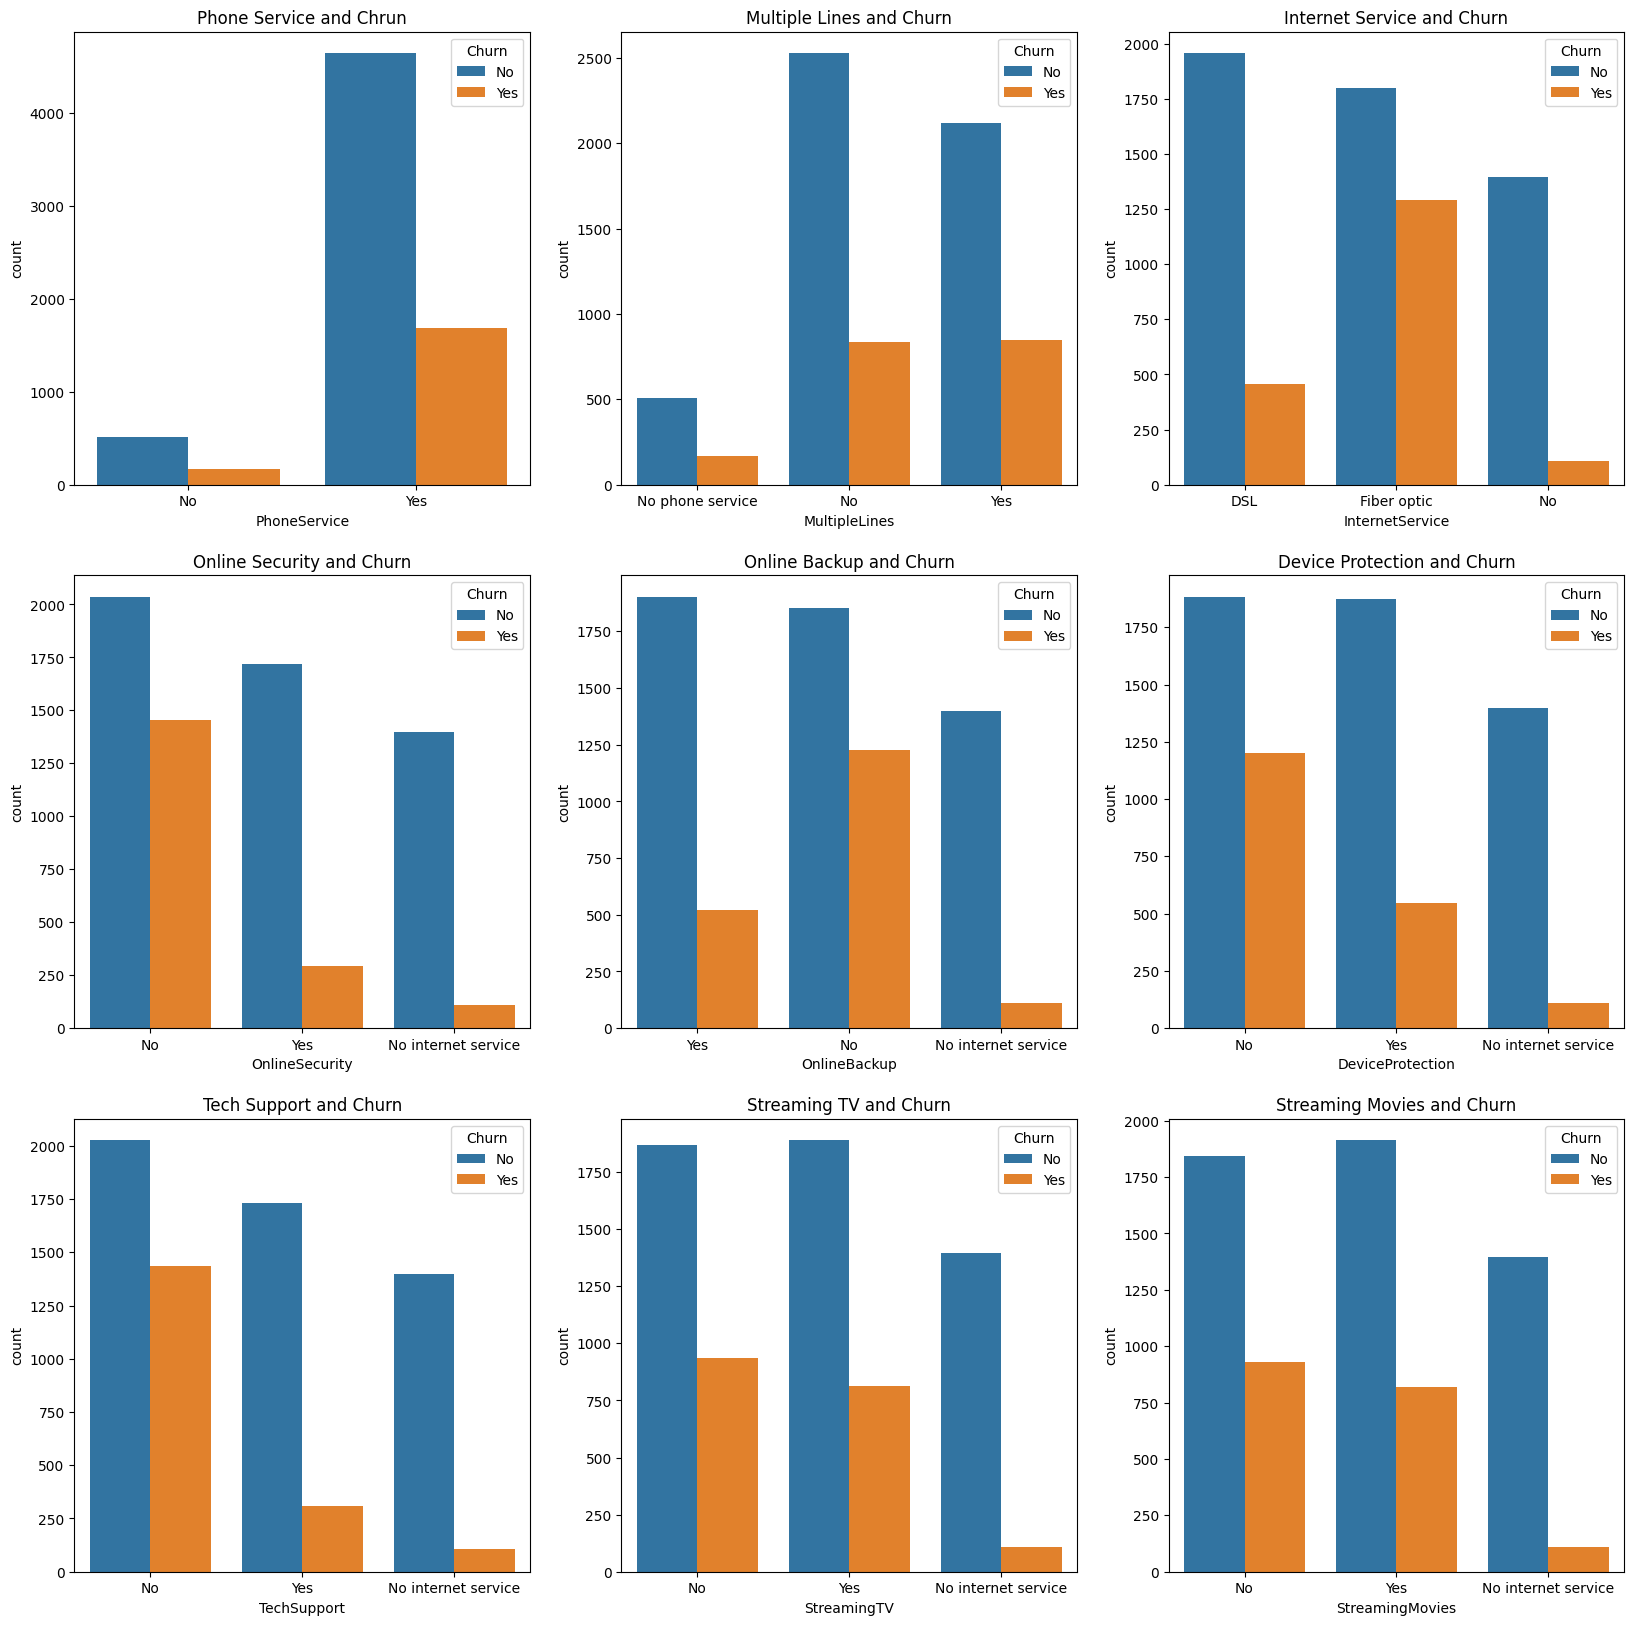

In [30]:
plt.figure(figsize=(20, 20))

#phone service
plt.subplot(3,3,1)
sns.countplot(x=df['PhoneService'],hue=df['Churn']).set_title("Phone Service and Chrun")

#Multiple Lines
plt.subplot(3,3,2)
sns.countplot(x=df['MultipleLines'],hue=df['Churn']).set_title("Multiple Lines and Churn")

#Internet Service
plt.subplot(3,3,3)
sns.countplot(x=df['InternetService'],hue=df['Churn']).set_title("Internet Service and Churn")

#Online Security
plt.subplot(3,3,4)
sns.countplot(x=df['OnlineSecurity'],hue=df['Churn']).set_title("Online Security and Churn")

#Online Backup
plt.subplot(3,3,5)
sns.countplot(x=df['OnlineBackup'],hue=df['Churn']).set_title("Online Backup and Churn")

#Device Protection
plt.subplot(3,3,6)
sns.countplot(x=df['DeviceProtection'],hue=df['Churn']).set_title("Device Protection and Churn")

#Tech Support
plt.subplot(3,3,7)
sns.countplot(x=df['TechSupport'],hue=df['Churn']).set_title("Tech Support and Churn")

#Streaming TV
plt.subplot(3,3,8)
sns.countplot(x=df['StreamingTV'],hue=df['Churn']).set_title("Streaming TV and Churn")

#Streaming Movies
plt.subplot(3,3,9)
sns.countplot(x=df['StreamingMovies'],hue=df['Churn']).set_title("Streaming Movies and Churn")

plt.show()

**Churn by Service Usage**

- Customers with phone service show higher churn in absolute numbers due to a larger user base.
- Customers without multiple lines tend to churn slightly more than those with multiple lines.
- Fiber optic users have the highest churn compared to DSL and non-internet users.
- Customers without online security are more likely to churn.
- Lack of online backup is associated with higher churn.
- Customers without device protection show higher churn behavior.
- Customers without tech support are more prone to churn.
- Streaming TV usage does not show a strong difference in churn behavior.
- Streaming movies usage also shows minimal impact on churn.

Customers lacking additional services (security, support, backup) and those using fiber optic internet are more likely to churn.

### Tenure/Contract and Churn

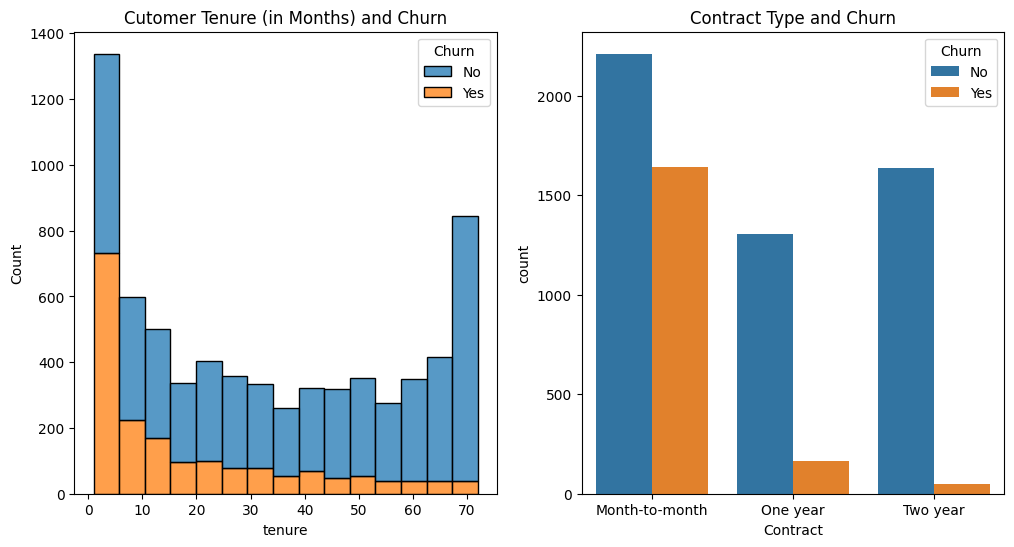

In [31]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
sns.histplot(x = 'tenure', data = df, hue='Churn', multiple = 'stack').set_title('Cutomer Tenure (in Months) and Churn') 

plt.subplot(1,2,2)
sns.countplot(x = 'Contract', data = df,hue='Churn').set_title('Contract Type and Churn')

plt.show()

**Churn by Tenure and Contract**

- Customers with shorter tenure (less than 5 months) have a higher churn rate.
- Churn rate decreases as tenure increases.
- Month-to-month contracts are associated with higher churn compared to one-year or two-year contracts.

Longer contracts and customer loyalty are linked to lower churn.

### Billing/Charges and Churn

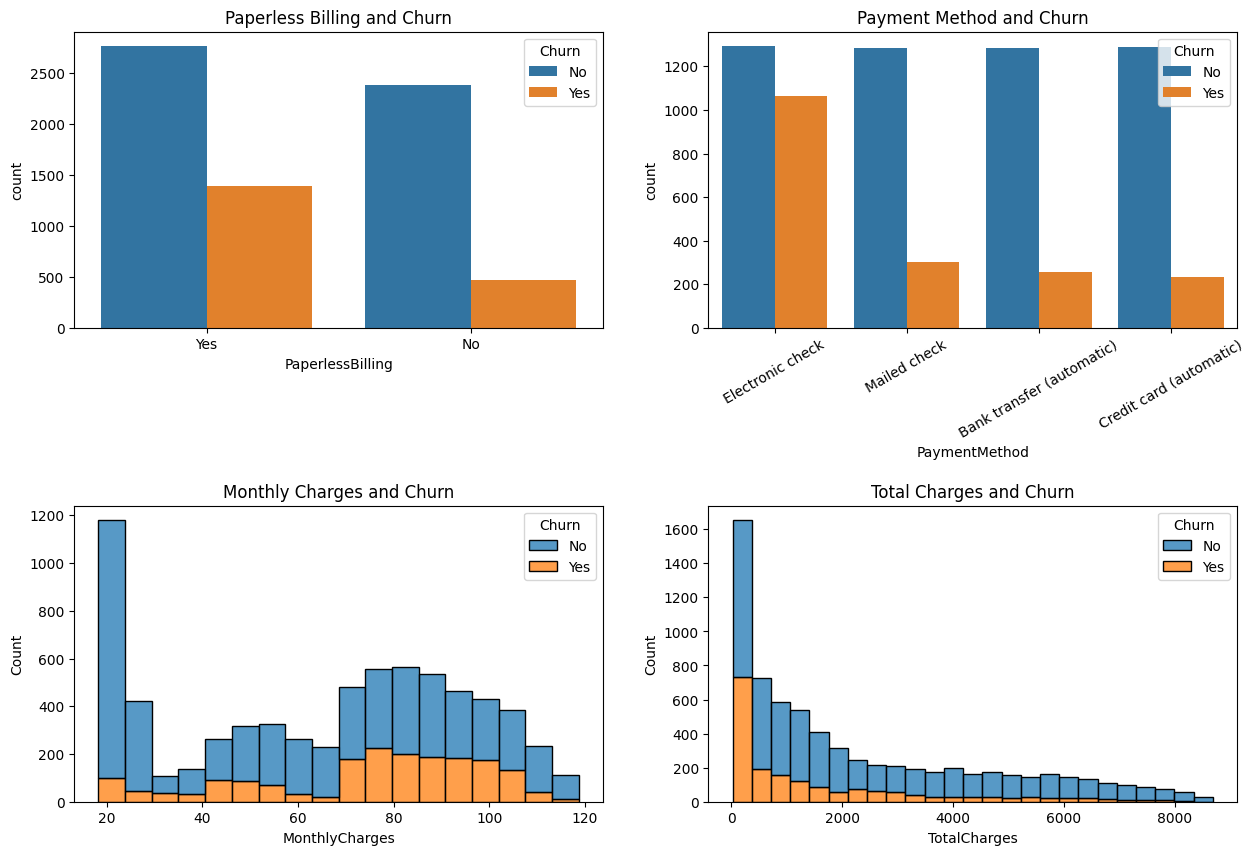

In [32]:
plt.figure(figsize=(15,10))
plt.subplots_adjust(hspace=.6)

#papaerless billing
plt.subplot(2,2,1)
sns.countplot(x = df['PaperlessBilling'],hue=df['Churn']).set_title('Paperless Billing and Churn')

#Payment Method
plt.subplot(2,2,2)
sns.countplot(x = df['PaymentMethod'],hue=df['Churn']).set_title('Payment Method and Churn')
plt.xticks(rotation=30)

#Monthly Charges
plt.subplot(2,2,3)
sns.histplot(x=df['MonthlyCharges'], hue = df['Churn'], multiple= 'stack').set_title("Monthly Charges and Churn")

#Total Charges
plt.subplot(2,2,4)
sns.histplot(x=df['TotalCharges'], hue = df['Churn'], multiple= 'stack').set_title("Total Charges and Churn")

plt.show()

**Churn by Billing and Charges**

- Customers using paperless billing tend to churn more than those who do not.
- Customers paying via electronic check show significantly higher churn compared to other payment methods.
- Higher monthly charges are associated with increased churn.
- Customers with lower total charges (shorter tenure) are more likely to churn.

Higher costs and certain payment behaviors, especially electronic check usage and paperless billing, are strong indicators of customer churn.

## Multivariate Analysis

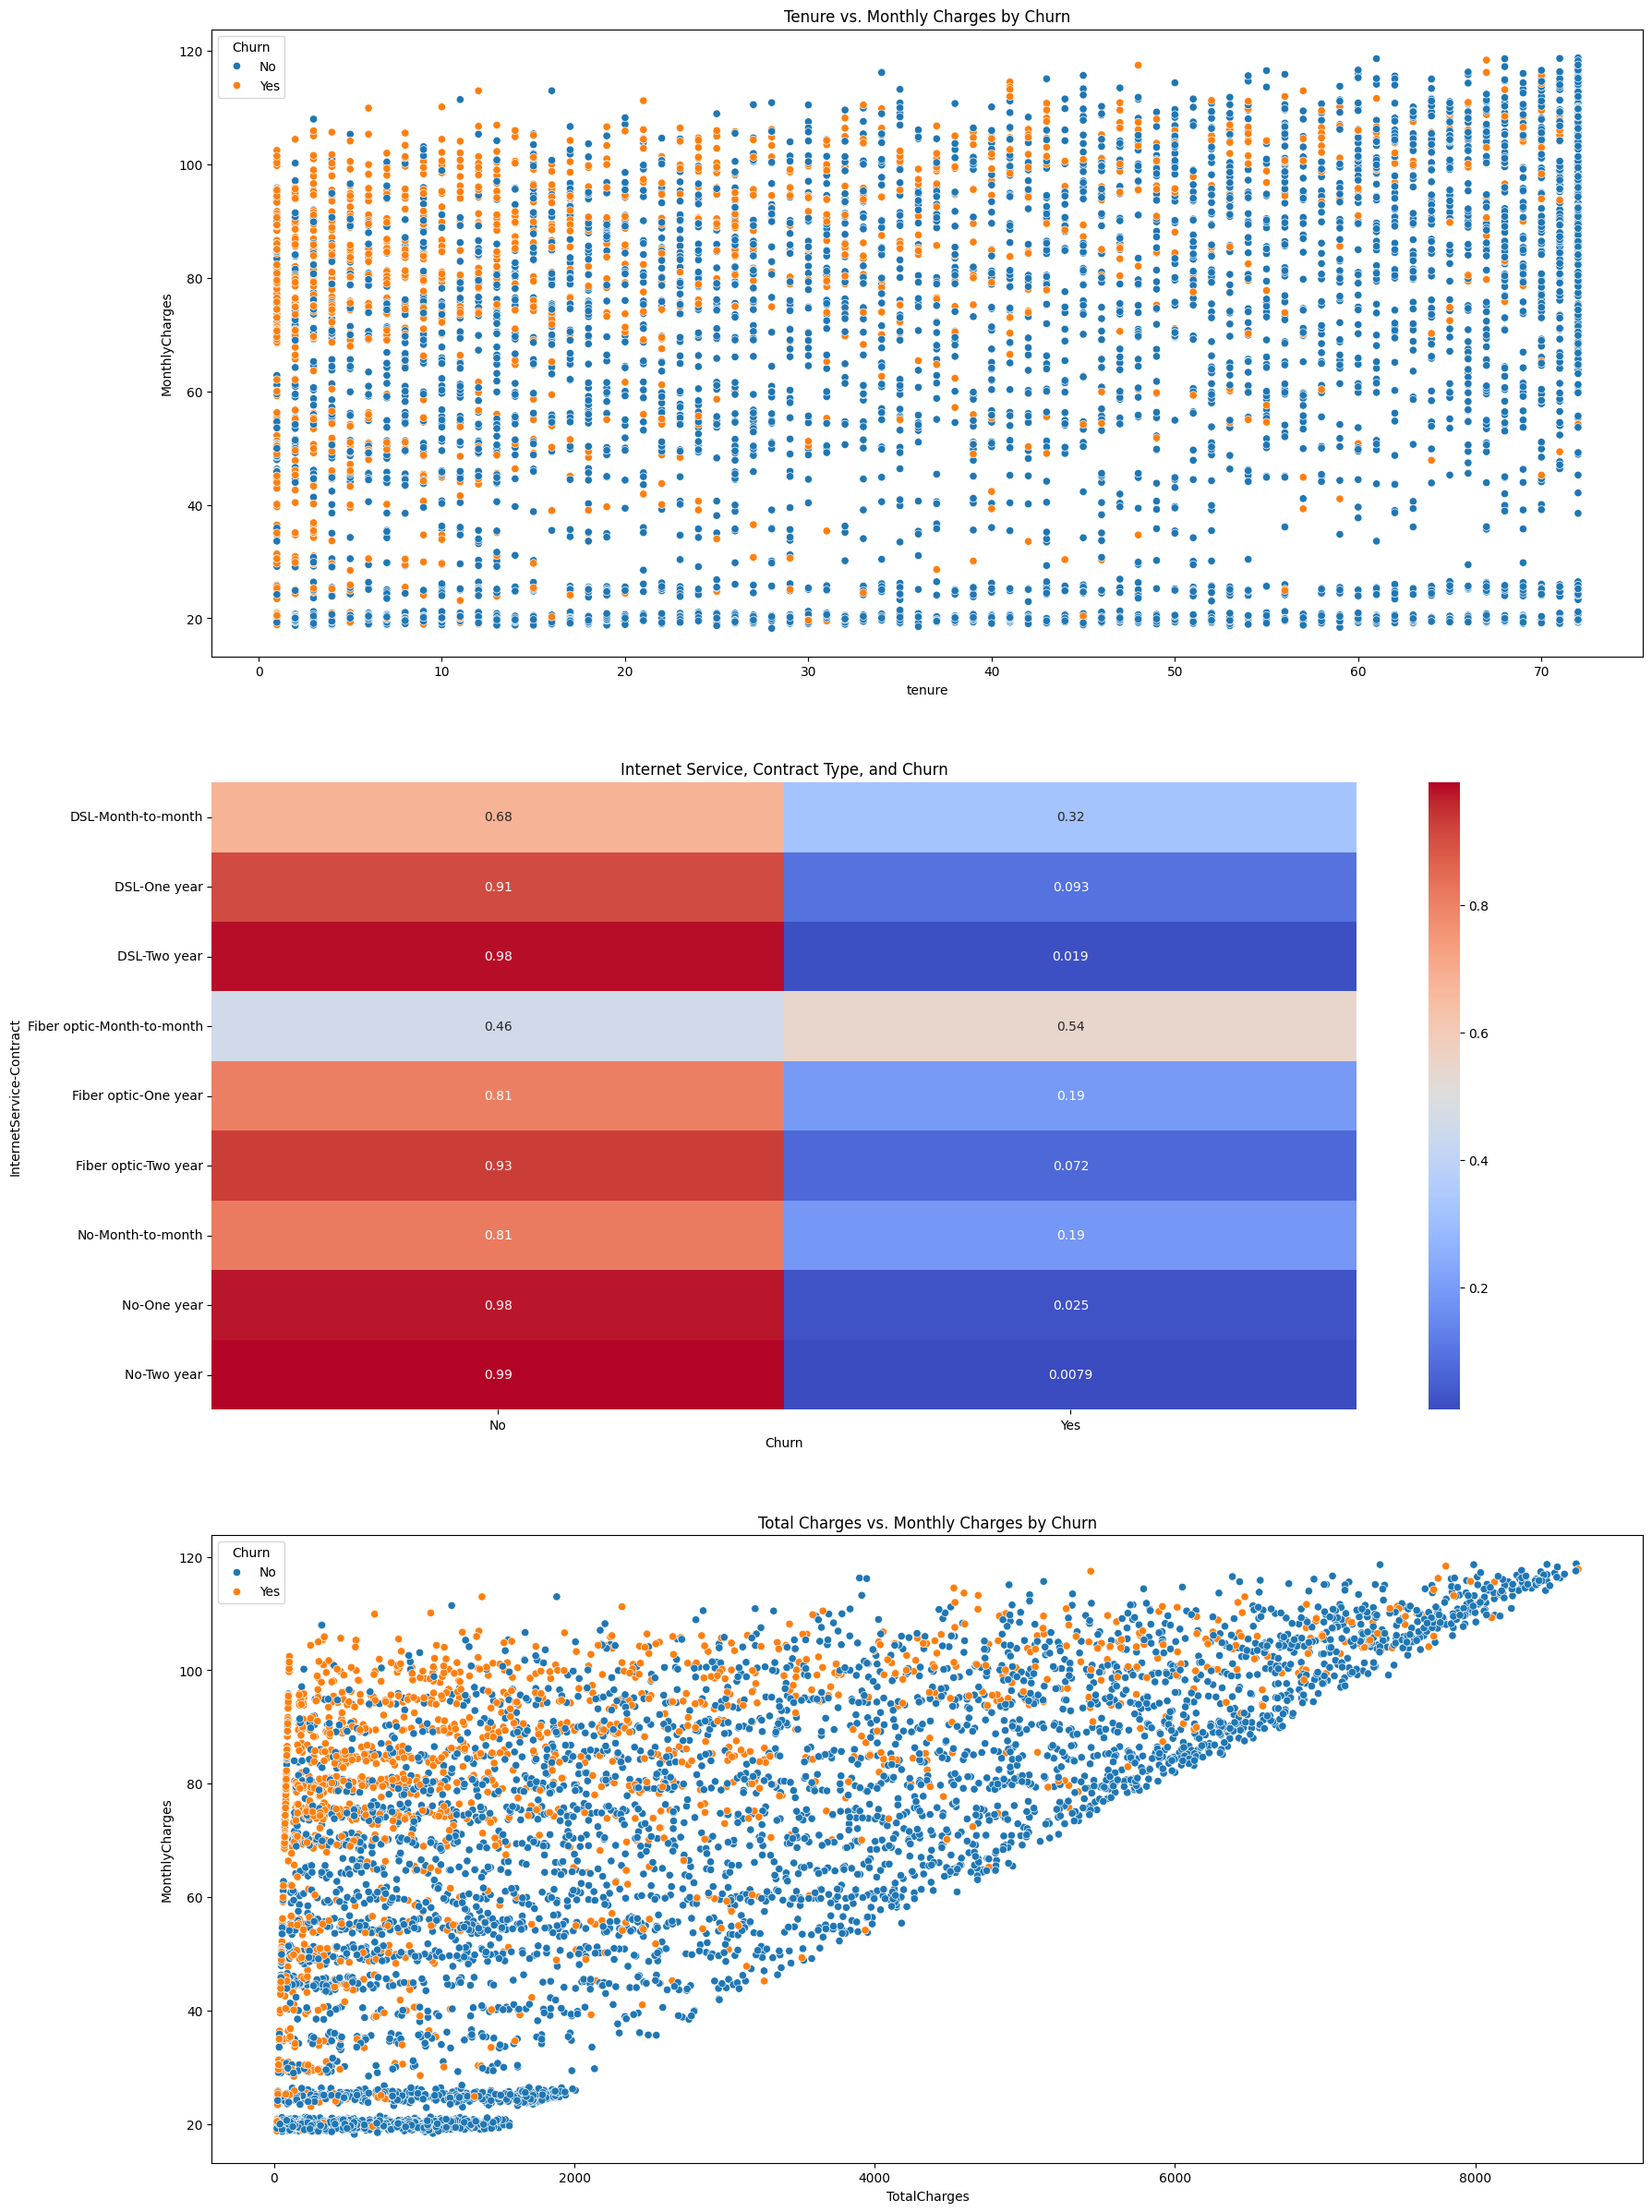

In [33]:
plt.figure(figsize=(20, 30))

plt.subplot(3, 1, 1)
sns.scatterplot(x=df["tenure"], y=df["MonthlyCharges"], hue=df["Churn"])
plt.title("Tenure vs. Monthly Charges by Churn")

plt.subplot(3, 1, 2)
sns.heatmap(pd.crosstab(index=[df['InternetService'], df['Contract']], columns=df['Churn'], normalize='index'), annot=True, cmap="coolwarm")
plt.title("Internet Service, Contract Type, and Churn")

plt.subplot(3, 1, 3)
sns.scatterplot(x=df["TotalCharges"], y=df["MonthlyCharges"], hue=df["Churn"])
plt.title("Total Charges vs. Monthly Charges by Churn")

plt.show()

**Multivariate Insights**

- Customers with short tenure and high monthly charges are more likely to churn.
- Month-to-month contracts, especially with fiber optic internet, have higher churn rates.
- Customers with high total charges (long-term customers) are less likely to churn, even if their monthly charges are high.

These patterns help identify high-risk customer segments.

## Outlier Removal

In [34]:
#Columns for outlier removal
cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

#Using IQR method to remove outliers
Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

#Removing the outliers
df = df[~((df[cols] < (Q1 - 1.5 * IQR)) |(df[cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

## Label Encoding

In [35]:
from sklearn.preprocessing import LabelEncoder

In [36]:
cols = df.columns[df.dtypes == 'str']
print("Categorical columns:", list(cols))

label_encoders = {}

for col in cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    
    print(f"{col} encoded values: {df[col].unique()}\n")

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
gender encoded values: [0 1]

Partner encoded values: [1 0]

Dependents encoded values: [0 1]

PhoneService encoded values: [0 1]

MultipleLines encoded values: [1 0 2]

InternetService encoded values: [0 1 2]

OnlineSecurity encoded values: [0 2 1]

OnlineBackup encoded values: [2 0 1]

DeviceProtection encoded values: [0 2 1]

TechSupport encoded values: [0 2 1]

StreamingTV encoded values: [0 2 1]

StreamingMovies encoded values: [0 2 1]

Contract encoded values: [0 1 2]

PaperlessBilling encoded values: [1 0]

PaymentMethod encoded values: [2 3 0 1]

Churn encoded values: [0 1]



## Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
#Standardizing the data
sc = StandardScaler()
df[['tenure', 'MonthlyCharges', 'TotalCharges']] = sc.fit_transform(df[['tenure', 'MonthlyCharges', 'TotalCharges']])

df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,-1.285566,0,1,0,0,2,0,0,0,0,0,1,2,-1.165523,-0.997284,0
1,1,0,0,0,0.060346,1,0,0,2,0,2,0,0,0,1,0,3,-0.264071,-0.176848,0
2,1,0,0,0,-1.244781,1,0,0,2,2,0,0,0,0,0,1,3,-0.367189,-0.962740,1


## Correlation Matrix Heatmap

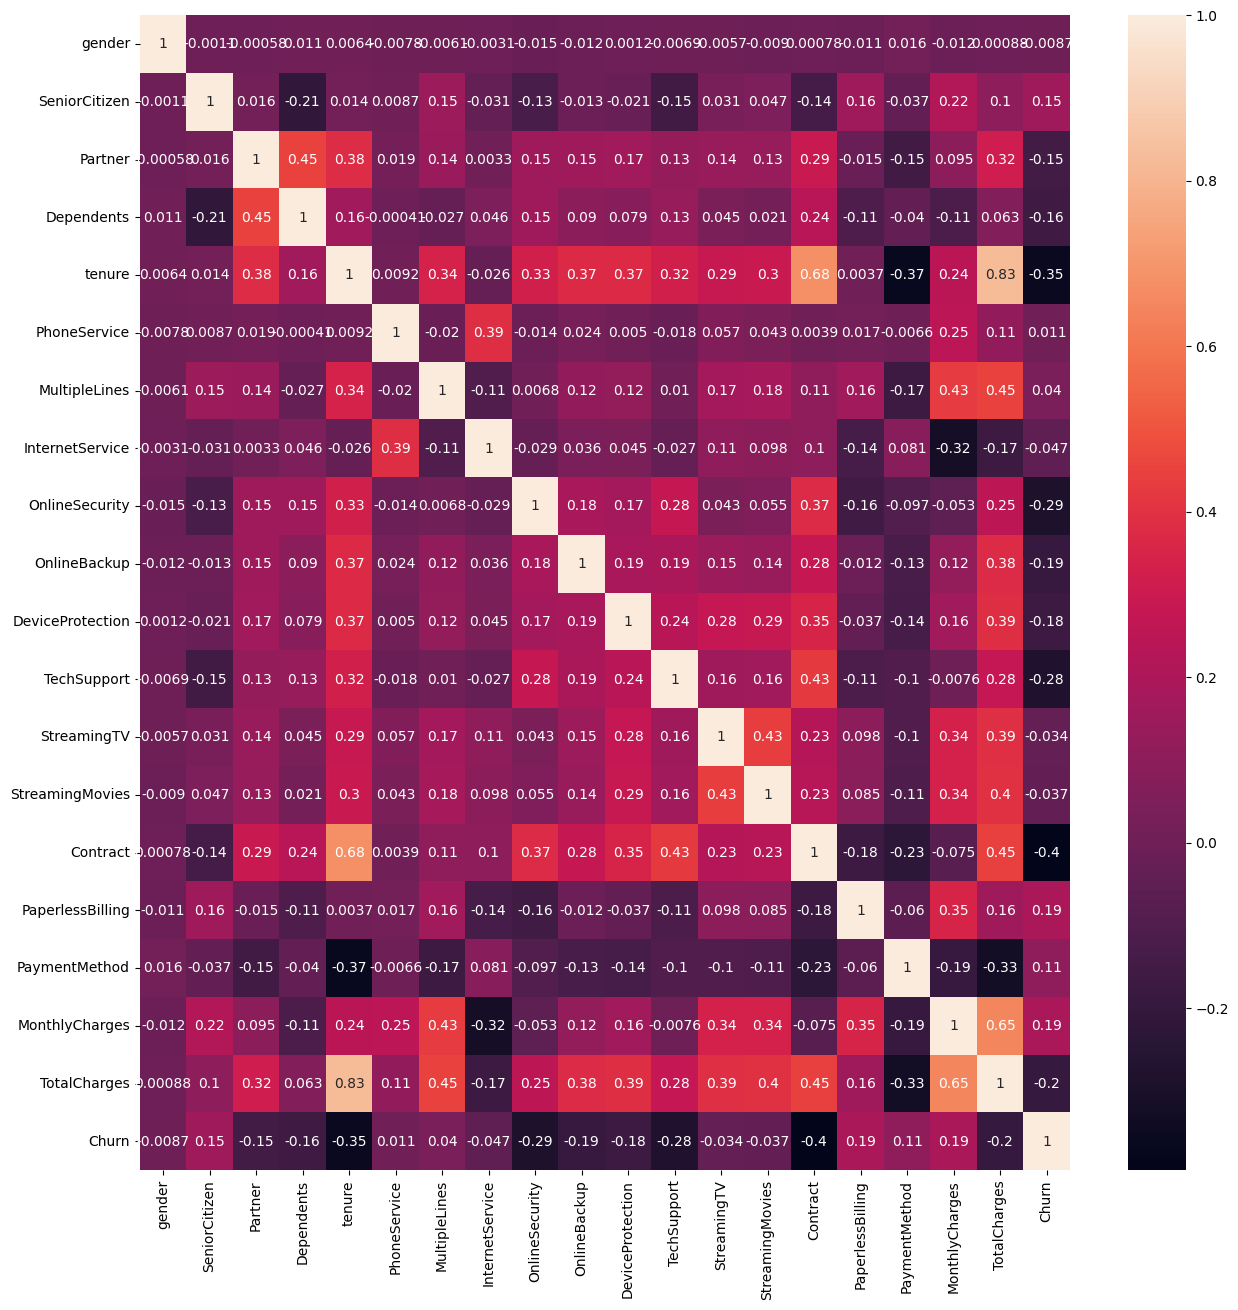

In [39]:
plt.figure(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True)
plt.show()

#### Now next section is Training and Testing Data on different Models.

## Train Test Split

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X=df.drop(columns='Churn')
y=df['Churn']

X.shape , y.shape

((7010, 19), (7010,))

In [42]:
y.value_counts()

Churn
0    5153
1    1857
Name: count, dtype: int64

In [43]:
# stratify=y ensures the model is trained on a representative dataset.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_train.shape , X_test.shape, y_train.shape, y_test.shape

((5608, 19), (1402, 19), (5608,), (1402,))

In [44]:
y_train.value_counts()

Churn
0    4122
1    1486
Name: count, dtype: int64

## **SMOTE (Synthetic Minority Over-sampling Technique)**

**SMOTE** is a data preprocessing technique used to handle imbalanced datasets by generating synthetic samples for the minority class instead of simply duplicating existing data.

**Correct Approach: Apply SMOTE After Splitting**

- Split the dataset first, so the test set remains untouched.
- Apply SMOTE only to the training set to balance the classes.
- Use the resampled training set for model training.

**SMOTE is applied when:**

- The dataset is highly imbalanced
- The minority class (e.g., churn customers) is important to predict
- Model performance on minority class is poor

**How it helps in this project?**

SMOTE helps by generating synthetic churn customer data, allowing the model to better learn churn patterns. This improves the model’s ability to correctly identify customers who are likely to leave, leading to better decision-making and customer retention strategies.

In [45]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply only on training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Check class distribution
print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_smote.value_counts())

Before SMOTE:
 Churn
0    4122
1    1486
Name: count, dtype: int64

After SMOTE:
 Churn
0    4122
1    4122
Name: count, dtype: int64


In [46]:
X_train_smote.shape, y_train_smote.shape

((8244, 19), (8244,))

In [ ]:
y_train_smote.value_counts()

Churn
0    4122
1    4122
Name: count, dtype: int64

## Model Building

#### Now the next Section is Model Building using different ML Models.

### 1. Logistic Regression

A linear model that estimates the probability of churn using a logistic function. It helps understand which factors increase/decrease churn probability

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize base model
lr = LogisticRegression(max_iter=500, random_state=42)

In [49]:
# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']  # supports both l1 and l2
}

In [50]:
# GridSearchCV
grid_lr = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [51]:
# Train on SMOTE data
grid_lr.fit(X_train_smote, y_train_smote)

# Best model
#best_lr = grid_lr.best_estimator_

print("Best Parameters:", grid_lr.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [52]:
# Logistic Regression with best parameters
lr = LogisticRegression(C=1, solver='liblinear', random_state=42, max_iter=500)

# Fitting the data
lr.fit(X_train_smote, y_train_smote)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [53]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

# Evaluation
print("\n        Logistic Regression Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


        Logistic Regression Results 

Accuracy: 0.7482168330955777

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1031
           1       0.52      0.75      0.61       371

    accuracy                           0.75      1402
   macro avg       0.70      0.75      0.71      1402
weighted avg       0.79      0.75      0.76      1402


Confusion Matrix:
 [[770 261]
 [ 92 279]]


### 2. Decision Tree Classifier

Decision Tree is a supervised machine learning algorithm that splits data into branches based on feature conditions to make predictions.

In [54]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt = DecisionTreeClassifier(random_state=42)

In [55]:
# Parameter grid
param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

In [56]:
# GridSearch
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [57]:
# Train on SMOTE data
grid_dt.fit(X_train_smote, y_train_smote)

# Best model
#best_dt = grid_dt.best_estimator_

print("Best Parameters:", grid_dt.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [58]:
# Decision Tree Classifier with best parameters
dt = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=10,  
    min_samples_split=10, 
    min_samples_leaf=2,
    random_state=42
)

#Fitting the data
dt.fit(X_train_smote, y_train_smote)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [59]:
# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

# Evaluation
print("\n       Decision Tree Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


       Decision Tree Results 

Accuracy: 0.7275320970042796

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.73      0.80      1031
           1       0.49      0.73      0.59       371

    accuracy                           0.73      1402
   macro avg       0.69      0.73      0.69      1402
weighted avg       0.78      0.73      0.74      1402


Confusion Matrix:
 [[749 282]
 [100 271]]


### 3. Random Forest

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [60]:
from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf = RandomForestClassifier(random_state=42)

In [61]:
# Parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

In [62]:
# GridSearch
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [63]:
# Train on SMOTE data
grid_rf.fit(X_train_smote, y_train_smote)

# Best model
#best_rf = grid_rf.best_estimator_

print("Best Parameters:", grid_rf.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [64]:
#Random Forest Classifier Object with best parameters
rf = RandomForestClassifier(
    n_estimators=100,
    criterion='gini', 
    max_depth=None, 
    min_samples_leaf=1, 
    min_samples_split=2, 
    random_state=42) 

#Fitting the data
rf.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [65]:
# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

# Evaluation
print("\n      Random Forest Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


      Random Forest Results 

Accuracy: 0.7731811697574893

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84      1031
           1       0.56      0.63      0.60       371

    accuracy                           0.77      1402
   macro avg       0.71      0.73      0.72      1402
weighted avg       0.78      0.77      0.78      1402


Confusion Matrix:
 [[850 181]
 [137 234]]


## 4. K-Nearest Neighbors (KNN)

K-Nearest Neighbors (KNN) is a supervised learning algorithm that classifies data points based on the majority class of their nearest neighbors. It uses distance measures to identify similar data points.

KNN is used because it classifies customers based on similarity with other customers, which helps in identifying churn patterns based on behavior.

In [66]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize model
knn = KNeighborsClassifier()

In [67]:
# Parameter grid
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [68]:
# GridSearch
grid_knn = GridSearchCV(
    estimator=knn,
    param_grid=param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [69]:
# Train on SMOTE scaled data
grid_knn.fit(X_train_smote, y_train_smote)

# Best model
#best_knn = grid_knn.best_estimator_

print("Best Parameters:", grid_knn.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [70]:
#KNN Classifier Object with best parameters
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

#Fitting the data
knn.fit(X_train_smote, y_train_smote)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [71]:
# Predictions
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

# Evaluation
print("\n       KNN Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


       KNN Results 

Accuracy: 0.7139800285306704

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.75      0.79      1031
           1       0.47      0.62      0.54       371

    accuracy                           0.71      1402
   macro avg       0.66      0.68      0.66      1402
weighted avg       0.75      0.71      0.73      1402


Confusion Matrix:
 [[770 261]
 [140 231]]


## 5. Support Vector Machine (SVM)

Support Vector Machine (SVM) is a supervised learning algorithm that finds the optimal hyperplane to separate data into different classes. It maximizes the margin between classes to improve classification accuracy.

SVM is used because it creates an optimal boundary between classes by maximizing the margin, which improves classification performance.

In [72]:
from sklearn.svm import SVC

# Initialize model (probability=True for ROC-AUC)
svm = SVC(probability=True, random_state=42)

In [73]:
# Parameter grid
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

In [74]:
# GridSearch
grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [75]:
# Train on SMOTE  data
grid_svm.fit(X_train_smote, y_train_smote)

# Best model
#best_svm = grid_svm.best_estimator_

print("Best Parameters:", grid_svm.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [76]:
# SVM Classifier with best parameters
svm = SVC(probability=True, kernel='rbf', C=10, gamma='scale', random_state=42)

# Fitting the data
svm.fit(X_train_smote, y_train_smote)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [77]:
# Predictions
y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:,1]

# Evaluation
print("\n      SVM Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


      SVM Results

Accuracy: 0.7482168330955777

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.77      0.82      1031
           1       0.52      0.68      0.59       371

    accuracy                           0.75      1402
   macro avg       0.69      0.73      0.70      1402
weighted avg       0.78      0.75      0.76      1402


Confusion Matrix:
 [[796 235]
 [118 253]]


## 6. XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds decision trees sequentially to improve performance.

XGBoost is used because it provides high accuracy, handles complex patterns, and includes regularization, making it one of the best models for structured data like churn prediction.

In [78]:
from xgboost import XGBClassifier

# Initialize model
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [79]:
# Parameter grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

In [80]:
# GridSearch
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [81]:
# Train on SMOTE data
grid_xgb.fit(X_train_smote, y_train_smote)

# Best model
#best_xgb = grid_xgb.best_estimator_

print("Best Parameters:", grid_xgb.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}


In [82]:
# XGBoost Classifier with best parameters
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=7, 
    learning_rate=0.2, 
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss')

# Fitting the data
xgb.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [83]:
# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

# Evaluation
print("\n      XGBoost Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


      XGBoost Results

Accuracy: 0.7696148359486448

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1031
           1       0.56      0.65      0.60       371

    accuracy                           0.77      1402
   macro avg       0.71      0.73      0.72      1402
weighted avg       0.78      0.77      0.77      1402


Confusion Matrix:
 [[838 193]
 [130 241]]


In [84]:
print("\n        Logistic Regression Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


print("\n       Decision Tree Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


print("\n      Random Forest Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


print("\n       KNN Results \n")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


print("\n      SVM Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))


print("\n      XGBoost Results\n")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


        Logistic Regression Results 

Accuracy: 0.7482168330955777

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.75      0.81      1031
           1       0.52      0.75      0.61       371

    accuracy                           0.75      1402
   macro avg       0.70      0.75      0.71      1402
weighted avg       0.79      0.75      0.76      1402


Confusion Matrix:
 [[770 261]
 [ 92 279]]

       Decision Tree Results 

Accuracy: 0.7275320970042796

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.73      0.80      1031
           1       0.49      0.73      0.59       371

    accuracy                           0.73      1402
   macro avg       0.69      0.73      0.69      1402
weighted avg       0.78      0.73      0.74      1402


Confusion Matrix:
 [[749 282]
 [100 271]]

      Random Forest Results 

Accuracy: 0.7731811697574893

Classification Repor

## Model Evaluation

### Bar Graph of Models over Accuracy

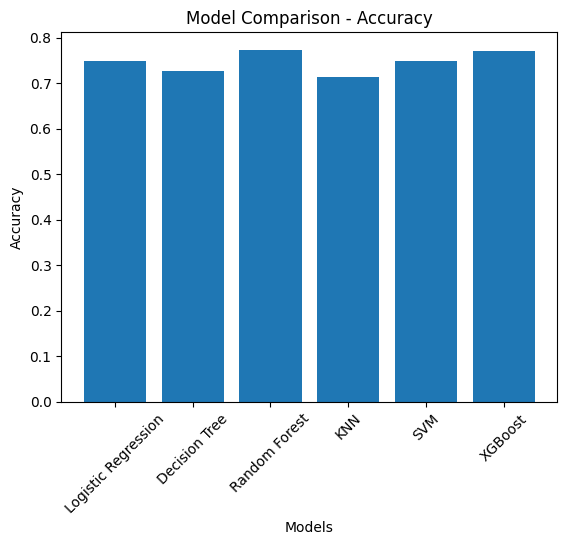

In [85]:
# Model names
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'KNN',
    'SVM',
    'XGBoost'
]

# Accuracy values (your results)
accuracy = [
    0.7482,
    0.7275,
    0.7731,
    0.7139,
    0.7482,
    0.7696
]

# Plot
plt.figure()
plt.bar(models, accuracy)

# Labels and title
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")

# Rotate x labels for clarity
plt.xticks(rotation=45)

# Show graph
plt.show()

### Confusion Matrix Heatmap

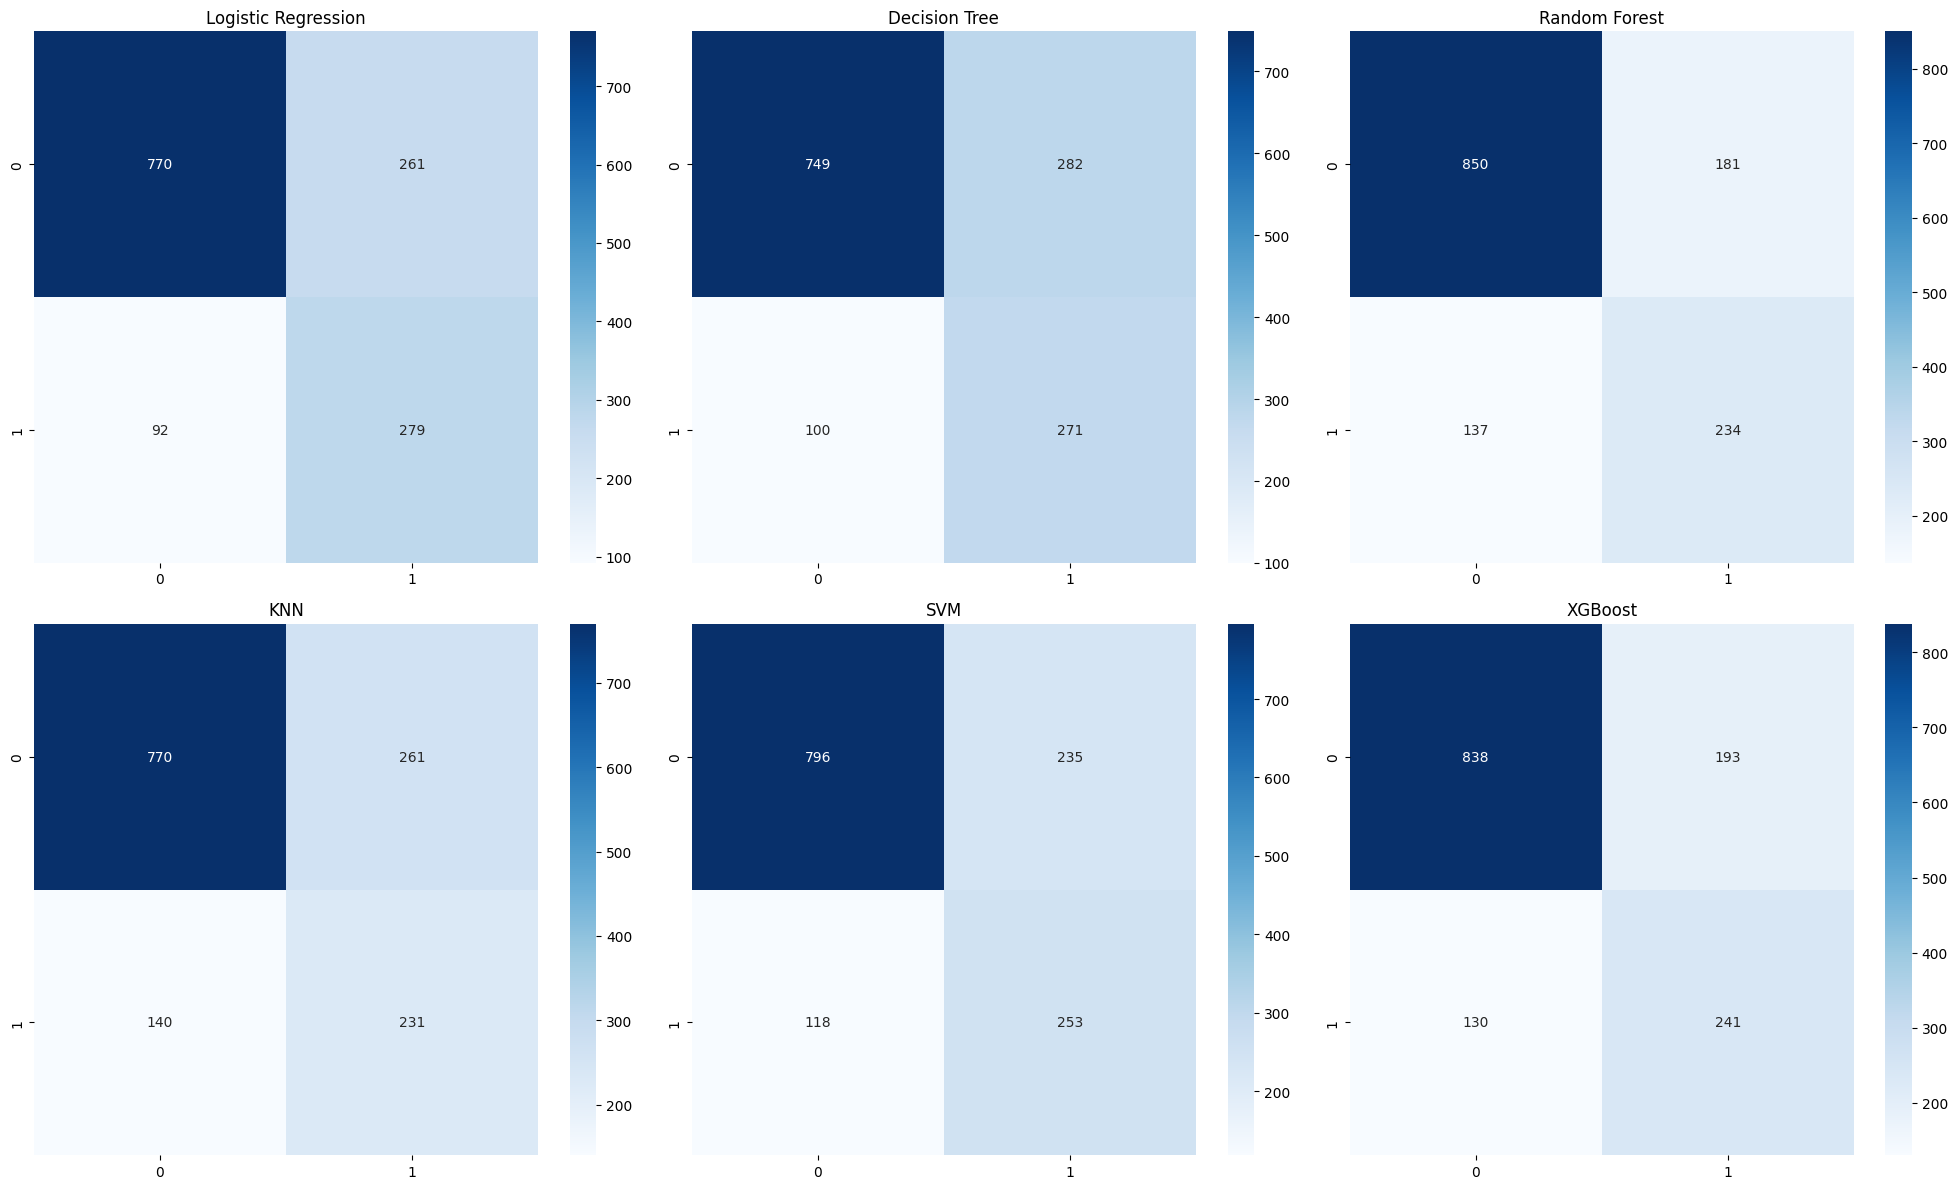

In [86]:
plt.figure(figsize=(20,12))

# Logistic Regression
plt.subplot(2,3,1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, cmap='Blues', fmt='d')
plt.title('Logistic Regression')

# Decision Tree
plt.subplot(2,3,2)
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, cmap='Blues', fmt='d')
plt.title('Decision Tree')

# Random Forest
plt.subplot(2,3,3)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, cmap='Blues', fmt='d')
plt.title('Random Forest')

# KNN
plt.subplot(2,3,4)
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, cmap='Blues', fmt='d')
plt.title('KNN')

# SVM
plt.subplot(2,3,5)
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, cmap='Blues', fmt='d')
plt.title('SVM')

# XGBoost
plt.subplot(2,3,6)
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, cmap='Blues', fmt='d')
plt.title('XGBoost')

plt.tight_layout()
plt.show()

## Model Performance Comparison

After training and evaluating all models, we compare their performance using accuracy, precision, recall, and F1-score.

### Model Ranking Table

| Rank | Model               | Accuracy | F1-Score (Churn Class) |
| ---- | ------------------- | -------- | ---------------------- |
| 1    | Random Forest       | 77.31%   | 0.60                   |
| 2    | XGBoost             | 76.96%   | 0.60                   |
| 3    | Logistic Regression | 74.82%   | 0.61                   |
| 4    | SVM                 | 74.82%   | 0.59                   |
| 5    | Decision Tree       | 72.75%   | 0.59                   |
| 6    | KNN                 | 71.39%   | 0.54                   |


### Top Performing Models

Based on the evaluation metrics, **Random Forest** emerged as the best-performing model with the highest accuracy of **77.31%** and a strong balance between precision and recall. **XGBoost** also performed exceptionally well with an accuracy of **76.96%**, closely following Random Forest. These models are considered the top performers due to their ensemble learning techniques, which improve prediction accuracy and robustness. **Logistic Regression** also showed good performance, particularly in terms of recall for churn customers, making it useful for identifying potential churn cases.

### Conclusion

**Random Forest** is the best performing model with the highest accuracy and balanced performance. 

**XGBoost and SVM** also show strong results, while **Logistic Regression** is effective for identifying churn customers due to its high recall. 

Simpler models like Decision Tree and KNN perform comparatively lower.

**The top models selected for further improvement are Random Forest, XGBoost, Logistic Regression, and SVM, as they provide the best overall performance.**

## Ensemble Learning

Ensemble learning is a technique that combines multiple machine learning models to improve overall prediction performance. Instead of relying on a single model, it aggregates the outputs of several models to produce better and more reliable results.

**Why we use Ensemble Learning**


In this project, ensemble learning is used to improve prediction accuracy and reduce errors by combining the strengths of multiple models. It helps in handling complex patterns in telecom churn data more effectively than individual models.

### Voting Classifier

Voting Classifier is an ensemble method that combines predictions from multiple models and makes a final decision based on majority voting (hard voting) or average probability (soft voting).


It is used to combine top-performing models like Random Forest, XGBoost, Logistic Regression, and SVM. This improves overall performance by leveraging the strengths of each model, resulting in more accurate and robust churn predictions.

In [87]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lr', lr),
        ('svm', svm)
    ],
    voting='soft'  # use probability(soft voting)
)

## Fit the Voting Classifier on SMOTE data
voting_model.fit(X_train_smote, y_train_smote)

y_pred_vote = voting_model.predict(X_test)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vote))
print("\n Classification Report:\n",classification_report(y_test, y_pred_vote))

Voting Classifier Accuracy: 0.7653352353780314

 Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83      1031
           1       0.55      0.67      0.60       371

    accuracy                           0.77      1402
   macro avg       0.71      0.74      0.72      1402
weighted avg       0.79      0.77      0.77      1402



#### Confusion Matrix of Voting Classifier Model

In [88]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_vote))


Confusion Matrix:
[[823 208]
 [121 250]]


#### Now use GridSearchCV to automatically find the best weights for Voting Classifier.

Assign **weights** based on model performance, where better-performing models were given higher importance in the ensemble.

In [89]:
from sklearn.model_selection import GridSearchCV

# Smart weight combinations (based on models result)
param_grid = {
    'weights': [
        [3, 3, 2, 1],   # RF & XGB highest
        [4, 4, 2, 1],   # stronger RF & XGB
        [5, 4, 2, 1],   # RF slightly higher
        [4, 5, 2, 1],   # XGB slightly higher
        [3, 3, 3, 1],   # LR also important
        [4, 4, 3, 1]    # balanced strong combo
    ]
}

# GridSearch
grid_vote = GridSearchCV(
    estimator=voting_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train
grid_vote.fit(X_train_smote, y_train_smote)

# Best model
#best_voting_model = grid_vote.best_estimator_

print("Best Weights:", grid_vote.best_params_)
print("Best CV Score:", grid_vote.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Weights: {'weights': [3, 3, 2, 1]}
Best CV Score: 0.8374722053909345


#### Now use this Best Weights[3,3,2,1] in new Voting Classifier Model.

In [90]:
voting_model_new = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lr', lr),
        ('svm', svm)
    ],
    voting='soft',  # use probability(soft voting)
    weights=[3, 3, 2, 1]  # RF & XGB with highest weights
)

## Fit the Voting Classifier on SMOTE data
voting_model_new.fit(X_train_smote, y_train_smote)

y_pred_vote = voting_model_new.predict(X_test)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_vote))
print("\n Classification Report:\n",classification_report(y_test, y_pred_vote))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_vote))

Voting Classifier Accuracy: 0.7731811697574893

 Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.81      0.84      1031
           1       0.56      0.68      0.61       371

    accuracy                           0.77      1402
   macro avg       0.72      0.74      0.73      1402
weighted avg       0.79      0.77      0.78      1402


Confusion Matrix:
[[831 200]
 [118 253]]


## Voting_Model_New (Final Model) 

**Voting_Model_New** is an ensemble machine learning model that combines predictions from multiple individual models such as **Logistic Regression, SVM, Random Forest, and XGBoost** to improve overall performance.

It works on the principle that multiple models together make better predictions than a single model. Each model independently predicts whether a customer will churn, and the final output is determined by combining these predictions using a voting mechanism (hard or soft voting).

#### This approach helps to:

- **Increase accuracy** by leveraging strengths of different algorithms

- **Reduce overfitting** compared to individual models

- **Improve robustness and stability** of predictions

- **Handle complex patterns** in telecom customer data effectively

As a result, voting_model_new provides more reliable and consistent churn predictions, making it the best model for this project.

## 📊 Final Model Comparison Table

| Model                | Accuracy  | Precision (Churn=1) | Recall (Churn=1) | f1-score (Churn=1) |
| -------------------- | --------- | ------------------- | ---------------- | ----------------   |
| Logistic Regression  | 0.748     | 0.52                | 0.75             | 0.61               |
| Decision Tree        | 0.727     | 0.49                | 0.73             | 0.59               |
| Random Forest        | 0.773     | 0.56                | 0.63             | 0.60               |
| KNN                  | 0.713     | 0.47                | 0.62             | 0.54               |
| SVM                  | 0.748     | 0.52                | 0.68             | 0.59               |
| XGBoost              | 0.769     | 0.56                | 0.65             | 0.60               |
| Voting Classifier    | 0.765     | 0.55                | 0.67             | 0.60               |
| **Voting_Model_New** | **0.773** | **0.56**            | **0.68**         | **0.61**           |


## Visualization of Models Performance

In [91]:

# Model performance summary
model_data = {
    'Model': ['Logistic Regression','Decision Tree', 'Random Forest', 'KNN', 'SVM', 'XGBoost', 'Voting Classifier'],
    'Accuracy': [0.7482, 0.7275, 0.7731, 0.7139, 0.7482, 0.7696, 0.7731],
    'F1-Score (Churn)': [0.61, 0.59, 0.60, 0.54, 0.59, 0.60, 0.61],
    'Recall (Churn)': [0.75, 0.73, 0.63, 0.62, 0.68, 0.65, 0.68]
}

df = pd.DataFrame(model_data)

In [92]:
print(model_data)

{'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM', 'XGBoost', 'Voting Classifier'], 'Accuracy': [0.7482, 0.7275, 0.7731, 0.7139, 0.7482, 0.7696, 0.7731], 'F1-Score (Churn)': [0.61, 0.59, 0.6, 0.54, 0.59, 0.6, 0.61], 'Recall (Churn)': [0.75, 0.73, 0.63, 0.62, 0.68, 0.65, 0.68]}


### Bar Graph for Accuracy

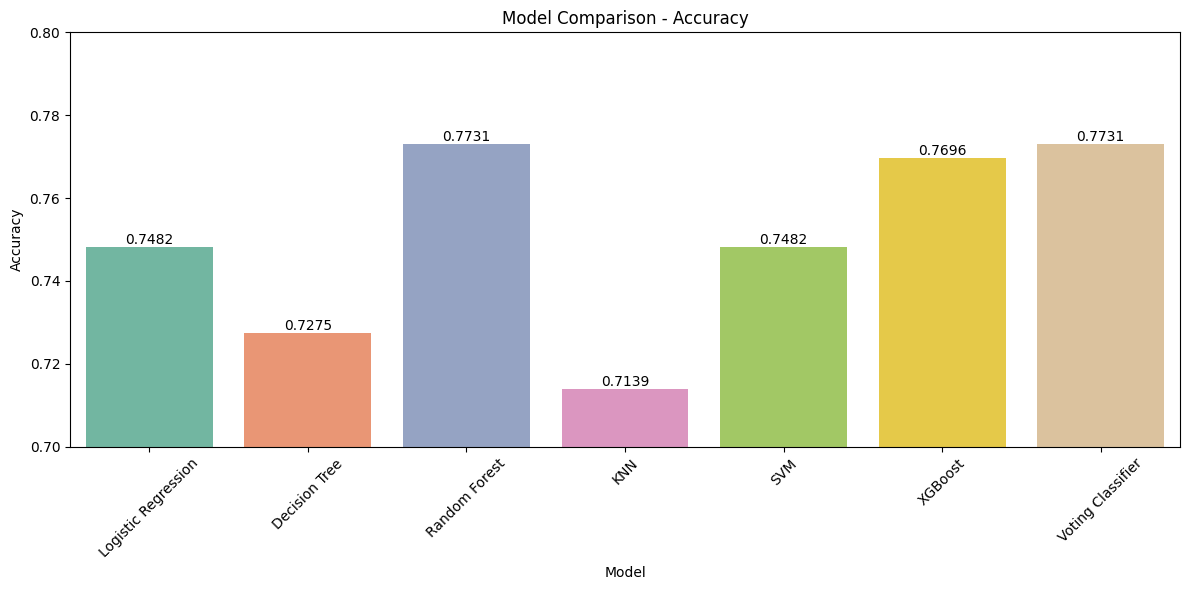

In [93]:
# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=df, palette='Set2')
plt.title('Model Comparison - Accuracy')
plt.xticks(rotation=45)
plt.ylim(0.70, 0.80)

# Annotate bars with accuracy values
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.4f}',            
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()

## Model Metrics

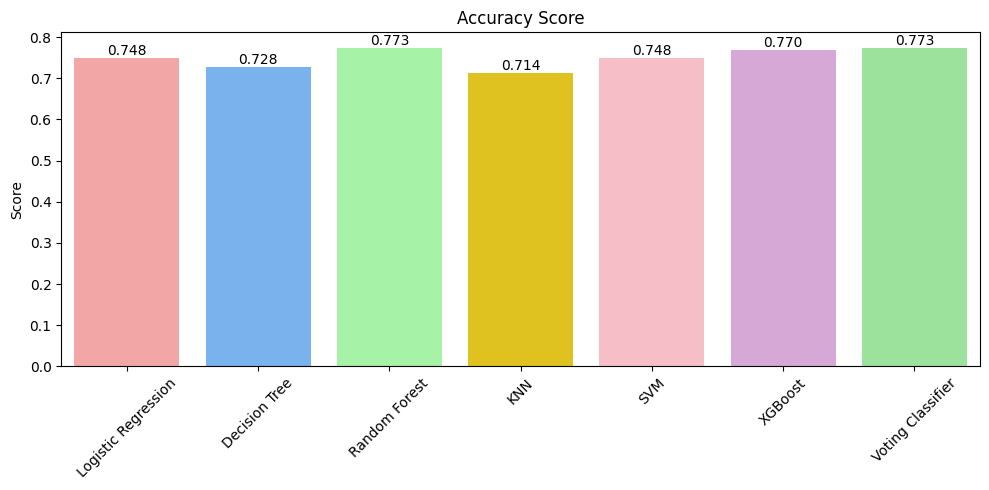

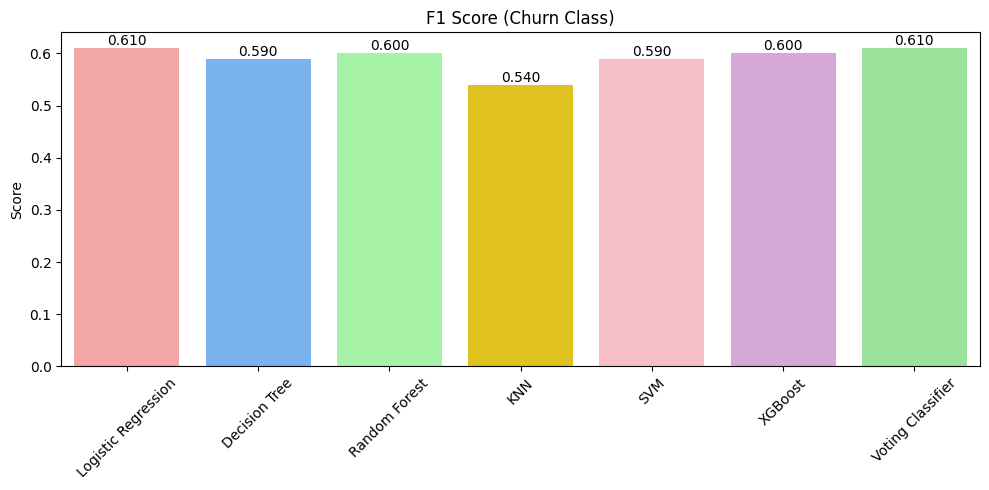

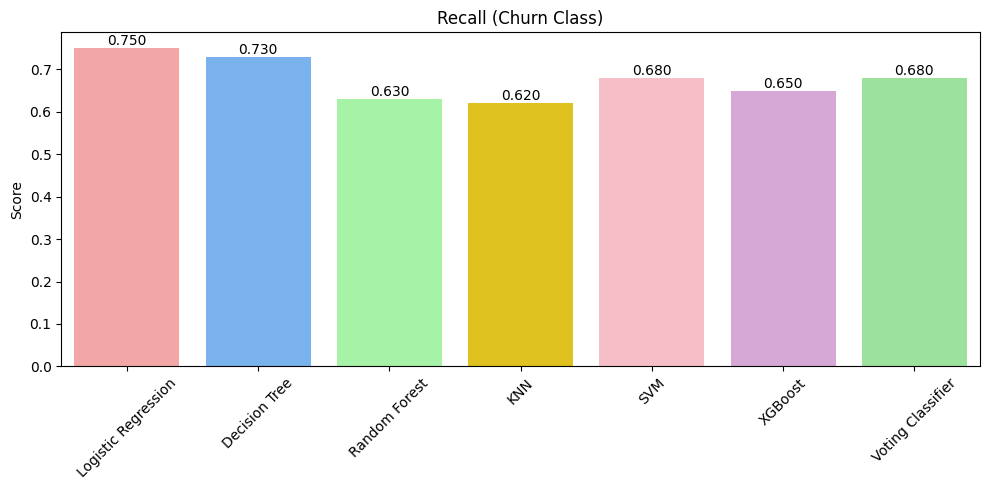

In [94]:
models = model_data['Model']

# Colors
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFD700', '#FFB6C1', '#DDA0DD', '#90EE90']

# Annotation function
def annotate_bars(ax, fmt=".3f"):
    for p in ax.patches:
        height = p.get_height()
        ax.annotate(f'{height:{fmt}}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

# Accuracy Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=models, y=model_data['Accuracy'], palette=colors)
plt.title('Accuracy Score')
plt.ylabel('Score')
plt.xticks(rotation=45)
annotate_bars(ax)
plt.tight_layout()
plt.show()

# F1 Score Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=models, y=model_data['F1-Score (Churn)'], palette=colors)
plt.title('F1 Score (Churn Class)')
plt.ylabel('Score')
plt.xticks(rotation=45)
annotate_bars(ax)
plt.tight_layout()
plt.show()

# Recall Plot
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=models, y=model_data['Recall (Churn)'], palette=colors)
plt.title('Recall (Churn Class)')
plt.ylabel('Score')
plt.xticks(rotation=45)
annotate_bars(ax)
plt.tight_layout()
plt.show()

## Feature Importance

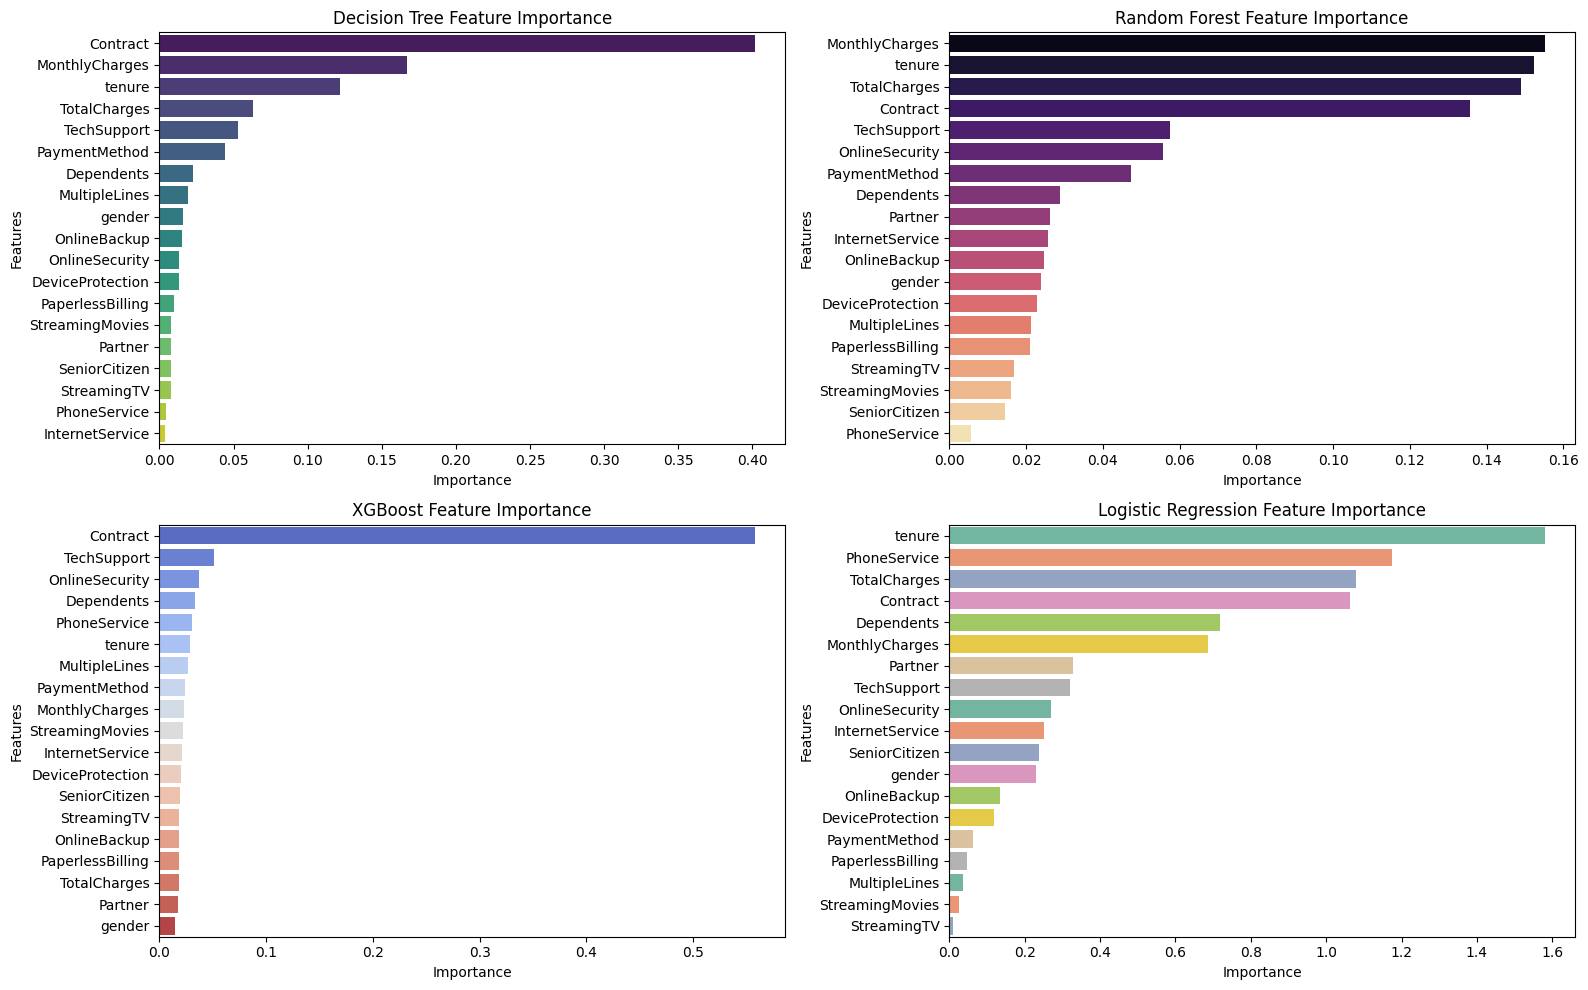

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.figure(figsize=(16, 10))

# ===============================
# Plot 1: Decision Tree
# ===============================
feature_df = pd.DataFrame({
    'Features': X.columns,
    'Importance': dt.feature_importances_
})
feature_df = feature_df.sort_values('Importance', ascending=False)

plt.subplot(2, 2, 1)
sns.barplot(x='Importance', y='Features', data=feature_df, palette='viridis')
plt.title('Decision Tree Feature Importance')


# ===============================
# Plot 2: Random Forest
# ===============================
feature_df = pd.DataFrame({
    'Features': X.columns,
    'Importance': rf.feature_importances_
})
feature_df = feature_df.sort_values('Importance', ascending=False)

plt.subplot(2, 2, 2)
sns.barplot(x='Importance', y='Features', data=feature_df, palette='magma')
plt.title('Random Forest Feature Importance')


# ===============================
# Plot 3: XGBoost
# ===============================
feature_df = pd.DataFrame({
    'Features': X.columns,
    'Importance': xgb.feature_importances_
})
feature_df = feature_df.sort_values('Importance', ascending=False)

plt.subplot(2, 2, 3)
sns.barplot(x='Importance', y='Features', data=feature_df, palette='coolwarm')
plt.title('XGBoost Feature Importance')


# ===============================
# Plot 4: Logistic Regression
# ===============================
feature_df = pd.DataFrame({
    'Features': X.columns,
    'Importance': np.abs(lr.coef_[0])
})
feature_df = feature_df.sort_values('Importance', ascending=False)

plt.subplot(2, 2, 4)
sns.barplot(x='Importance', y='Features', data=feature_df, palette='Set2')
plt.title('Logistic Regression Feature Importance')


# Final layout
plt.tight_layout()
plt.show()

In [96]:
# SVM Feature Importance (only works with linear kernel)
if hasattr(svm, "coef_"):
    # Create DataFrame with absolute values of coefficients
    feature_df = pd.DataFrame({
        'Features': X_train.columns,
        'Importance': abs(svm.coef_[0])
    })
    
    # Sort by importance
    feature_df.sort_values('Importance', ascending=False, inplace=True)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Features', data=feature_df, palette='viridis')
    plt.title('SVM (Linear Kernel) Feature Importance')
    plt.tight_layout()
    plt.show()
else:
    print("SVM model does not support coef_ (not a linear kernel).")

SVM model does not support coef_ (not a linear kernel).


##  📊 Feature Importance Support Across Models

| Model                         | Feature Importance Support | Method Used                       | Explanation                                                              |
| ----------------------------- | -------------------------- | --------------------------------- | ------------------------------------------------------------------------ |
| **Decision Tree**             | ✔ Yes                      | Built-in (`feature_importances_`) | Calculates importance based on feature splits using Gini/Entropy.        |
| **Random Forest**             | ✔ Yes                      | Built-in (`feature_importances_`) | Aggregates importance from multiple decision trees for better stability. |
| **XGBoost**                   | ✔ Yes                      | Built-in (`feature_importances_`) | Uses boosting metrics like gain, weight, and cover to rank features.     |
| **Logistic Regression**       | ✔ Yes                      | Coefficients (`coef_`)            | Weights indicate strength and direction of feature impact.               |
| **SVM (Linear)**              | ✔ Yes                      | Coefficients (`coef_`)            | Works only with linear kernel; coefficients show feature influence.      |
| **K-Nearest Neighbors (KNN)** | ❌ No                       | Not Available                     | Instance-based model; uses distance, not feature weights.                |
| **Voting Classifier**         | ❌ No                       | Not Directly Available            | Combines multiple models; cannot assign single feature importance.       |


## Saving Objects with joblib

In [100]:
import joblib

features = X_train.columns.tolist()
print(features)

joblib.dump({
    'model': voting_model_new,
    'scaler': sc,
    'label_encoders': label_encoders,
    'features': features
}, 'models/churn_pipeline.pkl')

print("\n✅ Saved inside models folder")

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

✅ Saved inside models folder
